In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

FigureTitle="Figure"

np.random.seed(1)
if not os.path.exists(FigureTitle):

   # Create a new directory because it does not exist
   os.makedirs(FigureTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

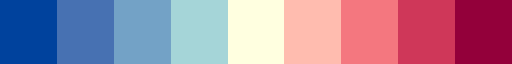

In [3]:
my_cmap

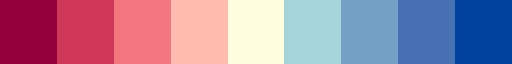

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1, Remove_exception=True):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    if Remove_exception==True:
        O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




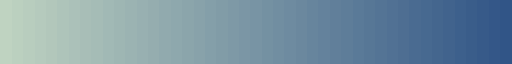

In [6]:
colors = ['#BFD3C1', '#6BA3D0', '#315587']
# Create a custom colormap with 45 distinct shades by interpolating between the base colors
color_list = [colors[0]]
num_steps = 45-2  # 45 distinct colors, minus the two base colors
for i in range(num_steps):
    r = (i + 1) / (num_steps + 1)
    interpolated_color = [
        int((1 - r) * int(colors[0][j:j+2], 16) + r * int(colors[2][j:j+2], 16))
        for j in (1, 3, 5)
    ]
    interpolated_color = "#{:02X}{:02X}{:02X}".format(*interpolated_color)
    color_list.append(interpolated_color)
color_list.append(colors[2])

cmap_1 = LinearSegmentedColormap.from_list('custom', color_list, N=45)
cmap_1

colors = ['#FF0000', '#FF7F7F', '#FFC0C0'][::-1]

# Create a custom colormap with 45 distinct shades of red by interpolating between the base colors
color_list = [colors[0]]
num_steps = 45 - 2  # 45 distinct colors, minus the two base colors
for i in range(num_steps):
    r = (i + 1) / (num_steps + 1)
    interpolated_color = [
        int((1 - r) * int(colors[0][j:j+2], 16) + r * int(colors[2][j:j+2], 16))
        for j in (1, 3, 5)
    ]
    interpolated_color = "#{:02X}{:02X}{:02X}".format(*interpolated_color)
    color_list.append(interpolated_color)
color_list.append(colors[2])

cmap_2 = LinearSegmentedColormap.from_list('custom', color_list, N=45)
cmap_1

In [7]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


def metric5(u,v,m):
    return SimilarityJS(u,m), SimilarityJS(v,m)

def metric6(u,v,m):
    return SimilarityJS(u,m,1e-4), SimilarityJS(v,m,1e-4)


def metric7(u,v,m):
    return np.sum(np.minimum(u,m))/np.sum(np.maximum(u,m)), np.sum(np.minimum(v,m))/np.sum(np.maximum(v,m))

def calculate_assymetricity(u,v,k):
    x=np.sqrt(np.array(u)**2+np.array(v)**2)
    y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)  
    return x,y


def characterize_case(x,y):
    if (x**2>0.5)*(y>0.5):
        return 0
    if (x**2>0.5)*(y<0.5):
        return 1
    if (x**2<0.5):
        return 2

In [8]:

def drawPairwiseChange(i, j, x):
    # This is just a sample function. Replace this with your function.
    return np.sin(i*x) + np.cos(j*x)

def InterpretPairwiseResult(y1,y2):
    if y1==1 and y2==1:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==0:
        return 'E',(0.85, 0.7, 0.7) #E : competitive exclusion
    elif y1==0 and y2==1:
        return 'B',(0.7, 0.7, 0.9) #B : Bistability
    elif y1>0 and y1<1 and y2>0 and y2<1:
        return 'C',(0.7, 0.85, 0.7) #C : Coexistence
    else:
        return 'U',(0.5, 0.5, 0.5) #U : Unclassified

def mask_equal(u,v,m):
    u_m=np.array(u)>0
    v_m=np.array(v)>0
    shared=u_m*v_m
    mask1=u_m-shared*(np.array(v)/(np.array(u)+np.array(v)+1e-8))
    mask2=1-mask1
    return mask1, mask2

def NbyNcomposition(Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    Coal_matrix={}
    Coal_keys={}
    Coal_mask1={}
    Coal_mask2={}
    Sub_keys={}
    Sub_matrix={}
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        subSampleIDX1=np.where(Sub_IDX_list==subSampleIDX1)[0][0]
        subSampleIDX2=np.where(Sub_IDX_list==subSampleIDX2)[0][0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_mix=df.values[1:].tolist()
        ID_mix=df.values[0]
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_1=df.values[1:].tolist()
        ID_1=df.values[0]   
        
        SampleIDX=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        c_2=df.values[1:].tolist()
        ID_2=df.values[0]          
        
        mask_1,mask_2=mask_equal(c_1,c_2,c_mix)
        
        
        i=min(subSampleIDX1,subSampleIDX2)
        j=max(subSampleIDX1,subSampleIDX2)
        Coal_matrix[i,j]=c_mix
        Coal_keys[i,j]=ID_mix
        Coal_mask1[i,j]=mask_1
        Coal_mask2[i,j]=mask_2
        
        
    for SampleIDX in Sub_IDX_list:
        IDX_list_=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in [SampleIDX]])
        if (IDX_list_.size==0):
            continue
        df=Processed_sequences_synthetic.iloc[IDX_list_]
        i=np.where(Sub_IDX_list==SampleIDX)[0][0]
        Sub_matrix[i]=df.values[1:].tolist()
        Sub_keys[i]=df.values[0]
        
    return Coal_matrix, Sub_matrix, Coal_keys, Sub_keys,Coal_mask1,Coal_mask2



########################################################
########################################################
# Fig 1-2
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

########################################################
########################################################
# Fig 1-3
########################################################
########################################################


In [9]:
-5*(-5>0)

0

In [10]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def calculate_assymetricity(u,v,k):
    x=np.sqrt(np.array(u)**2+np.array(v)**2)
    y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)  
    return x,y

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))


In [11]:
Nat_Coal_IDX

{'LN': ['P7-62',
  'P7-85',
  'P7-26',
  'P7-51',
  'P7-50',
  'P7-27',
  'P7-15',
  'P7-87',
  'P7-61',
  'P7-03',
  'P7-28',
  'P7-14',
  'P7-73',
  'P7-25',
  'P7-40',
  'P7-49',
  'P7-75',
  'P7-37',
  'P7-16',
  'P7-39',
  'P7-74',
  'P7-52',
  'P7-63',
  'P7-04',
  'P7-01',
  'P7-64',
  'P7-38',
  'P7-13',
  'P7-76',
  'P7-02'],
 'MN': ['P7-78',
  'P7-77',
  'P7-20',
  'P7-30',
  'P7-68',
  'P7-42',
  'P7-67',
  'P7-29',
  'P7-89',
  'P7-31',
  'P7-56',
  'P7-17',
  'P7-06',
  'P7-79',
  'P7-80',
  'P7-44',
  'P7-05',
  'P7-07',
  'P7-41',
  'P7-66',
  'P7-43',
  'P7-54',
  'P7-19',
  'P7-91',
  'P7-55',
  'P7-08',
  'P7-32',
  'P7-53',
  'P7-18',
  'P7-65'],
 'HN': ['P7-11',
  'P7-09',
  'P7-71',
  'P7-33',
  'P7-83',
  'P7-57',
  'P7-45',
  'P7-36',
  'P7-82',
  'P7-60',
  'P7-81',
  'P7-35',
  'P7-95',
  'P7-48',
  'P7-84',
  'P7-24',
  'P7-70',
  'P7-23',
  'P7-58',
  'P7-46',
  'P7-72',
  'P7-34',
  'P7-93',
  'P7-12',
  'P7-69',
  'P7-47',
  'P7-22',
  'P7-59',
  'P7-10',
 

30
30
30


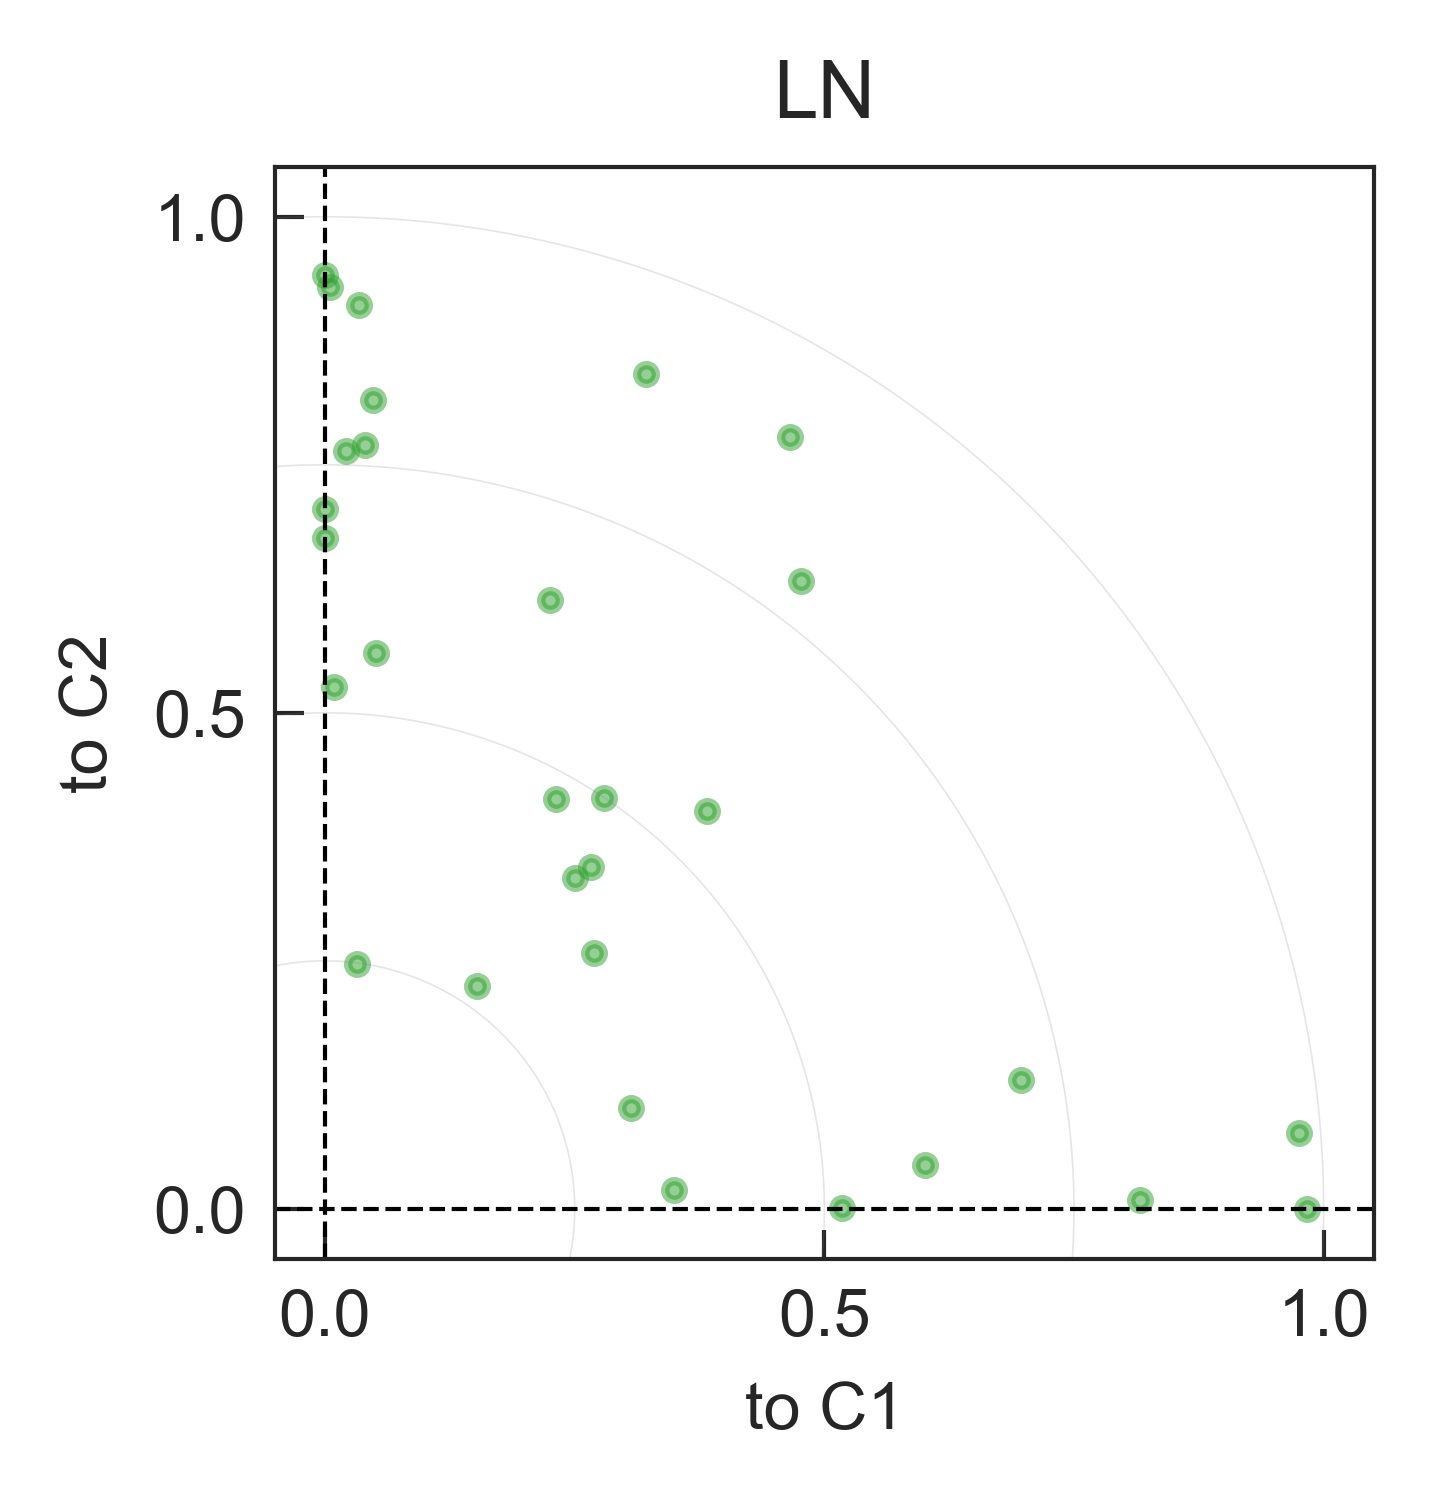

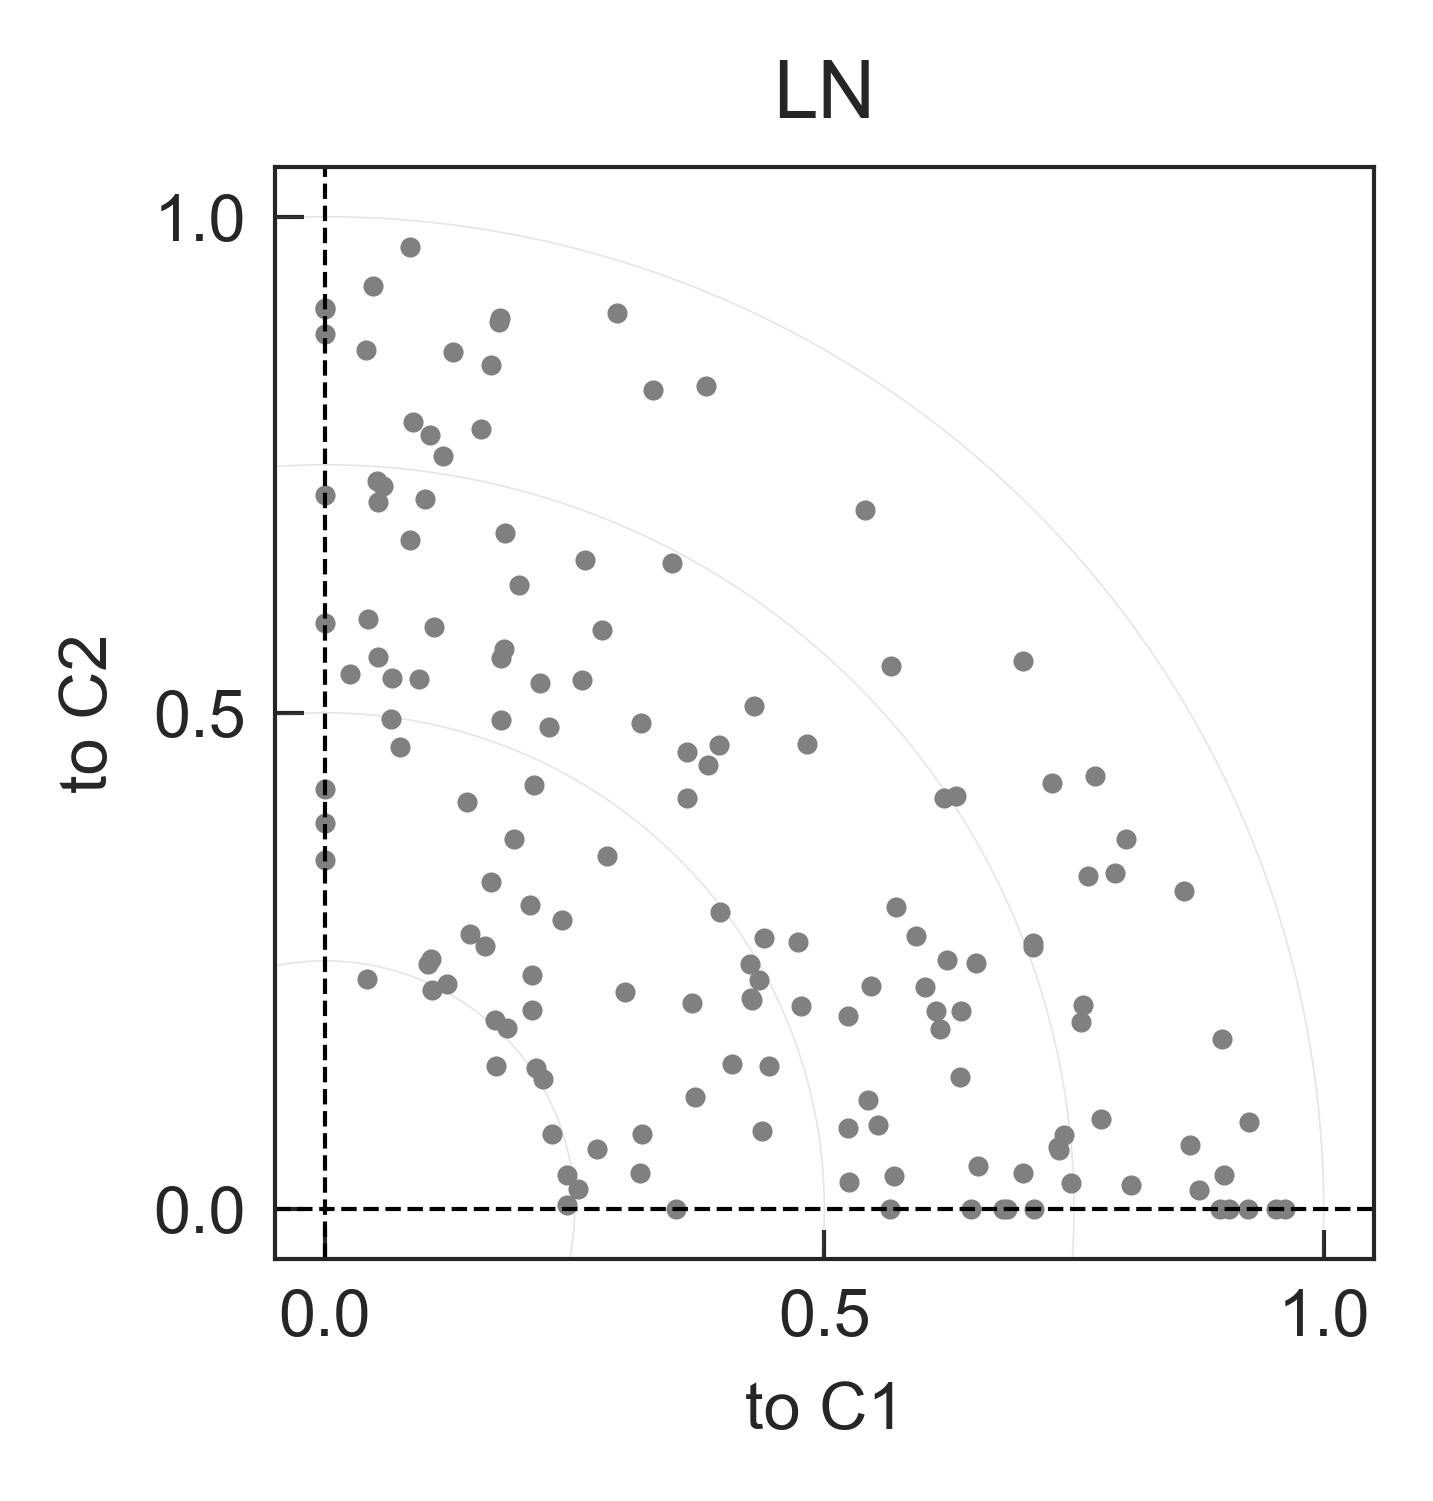

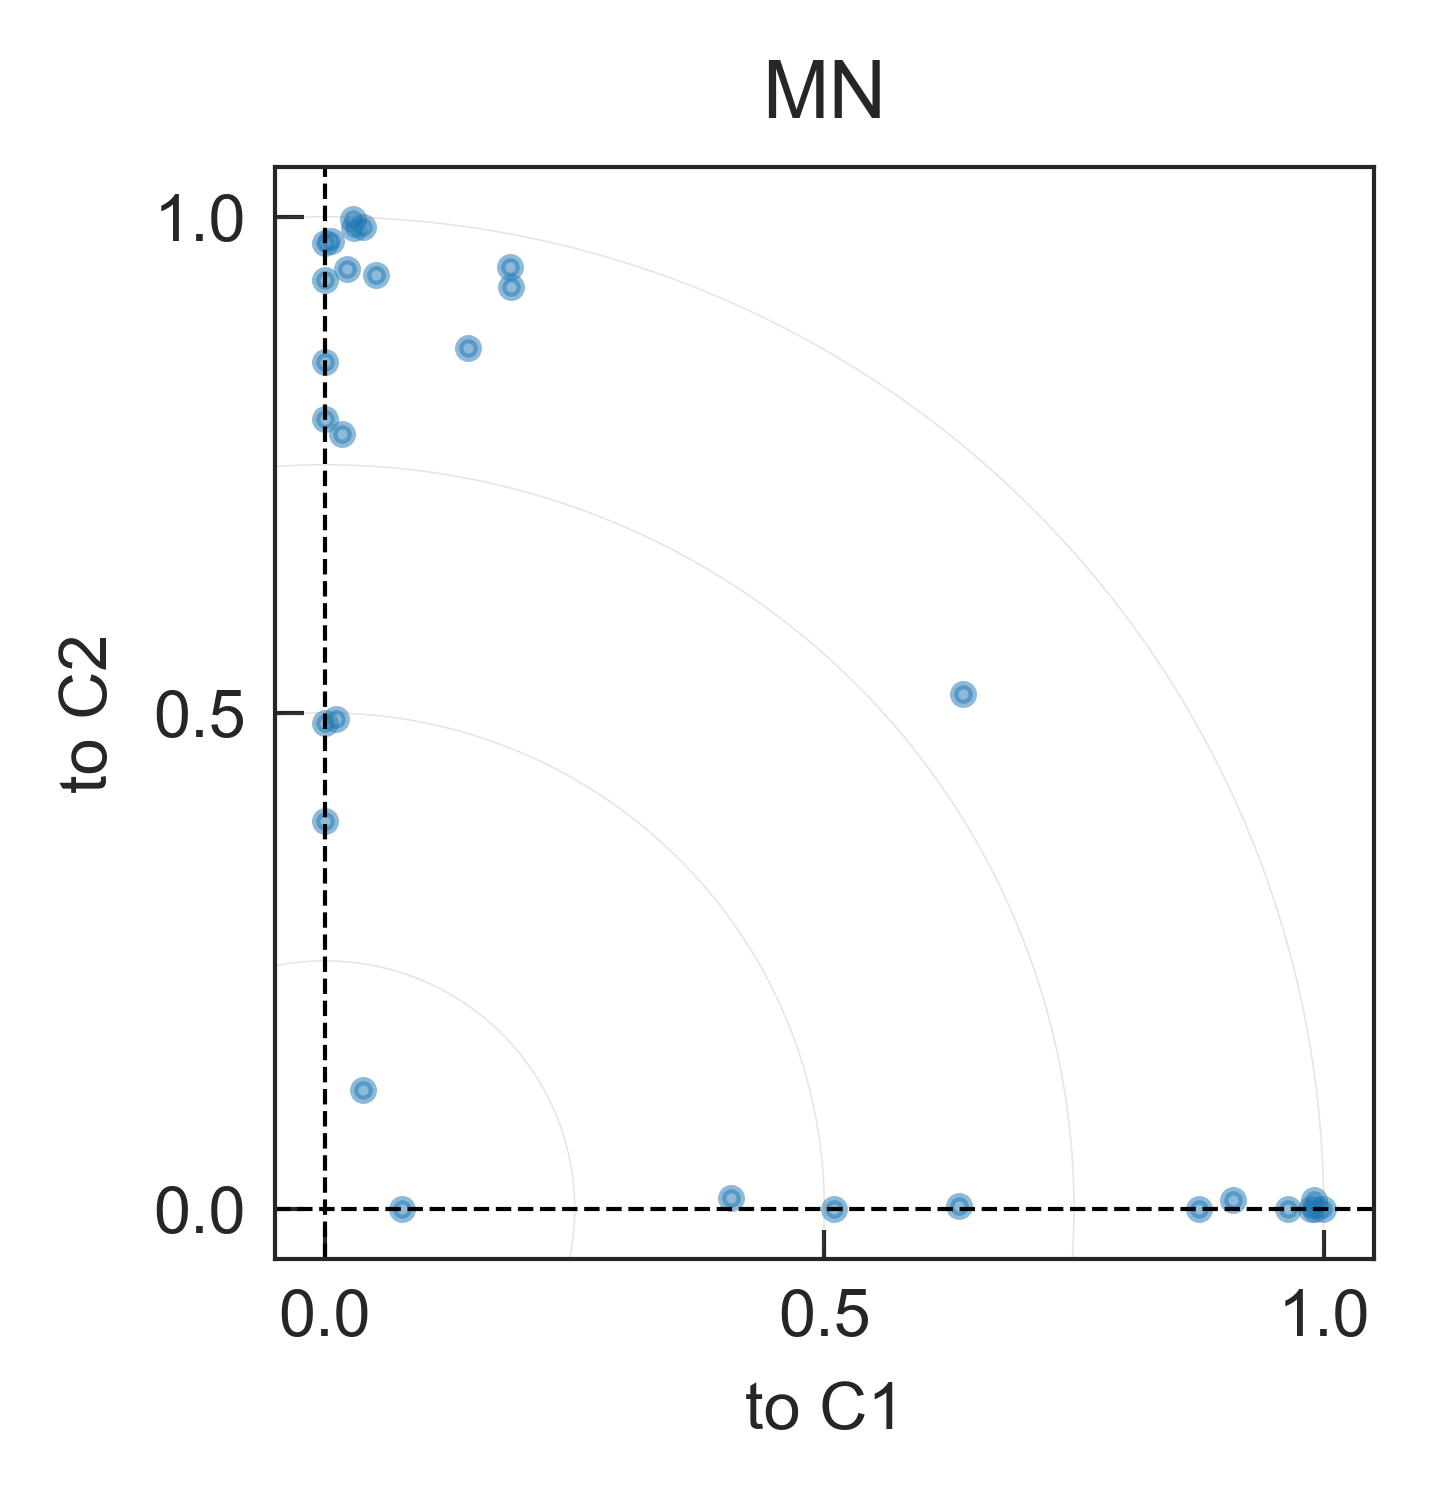

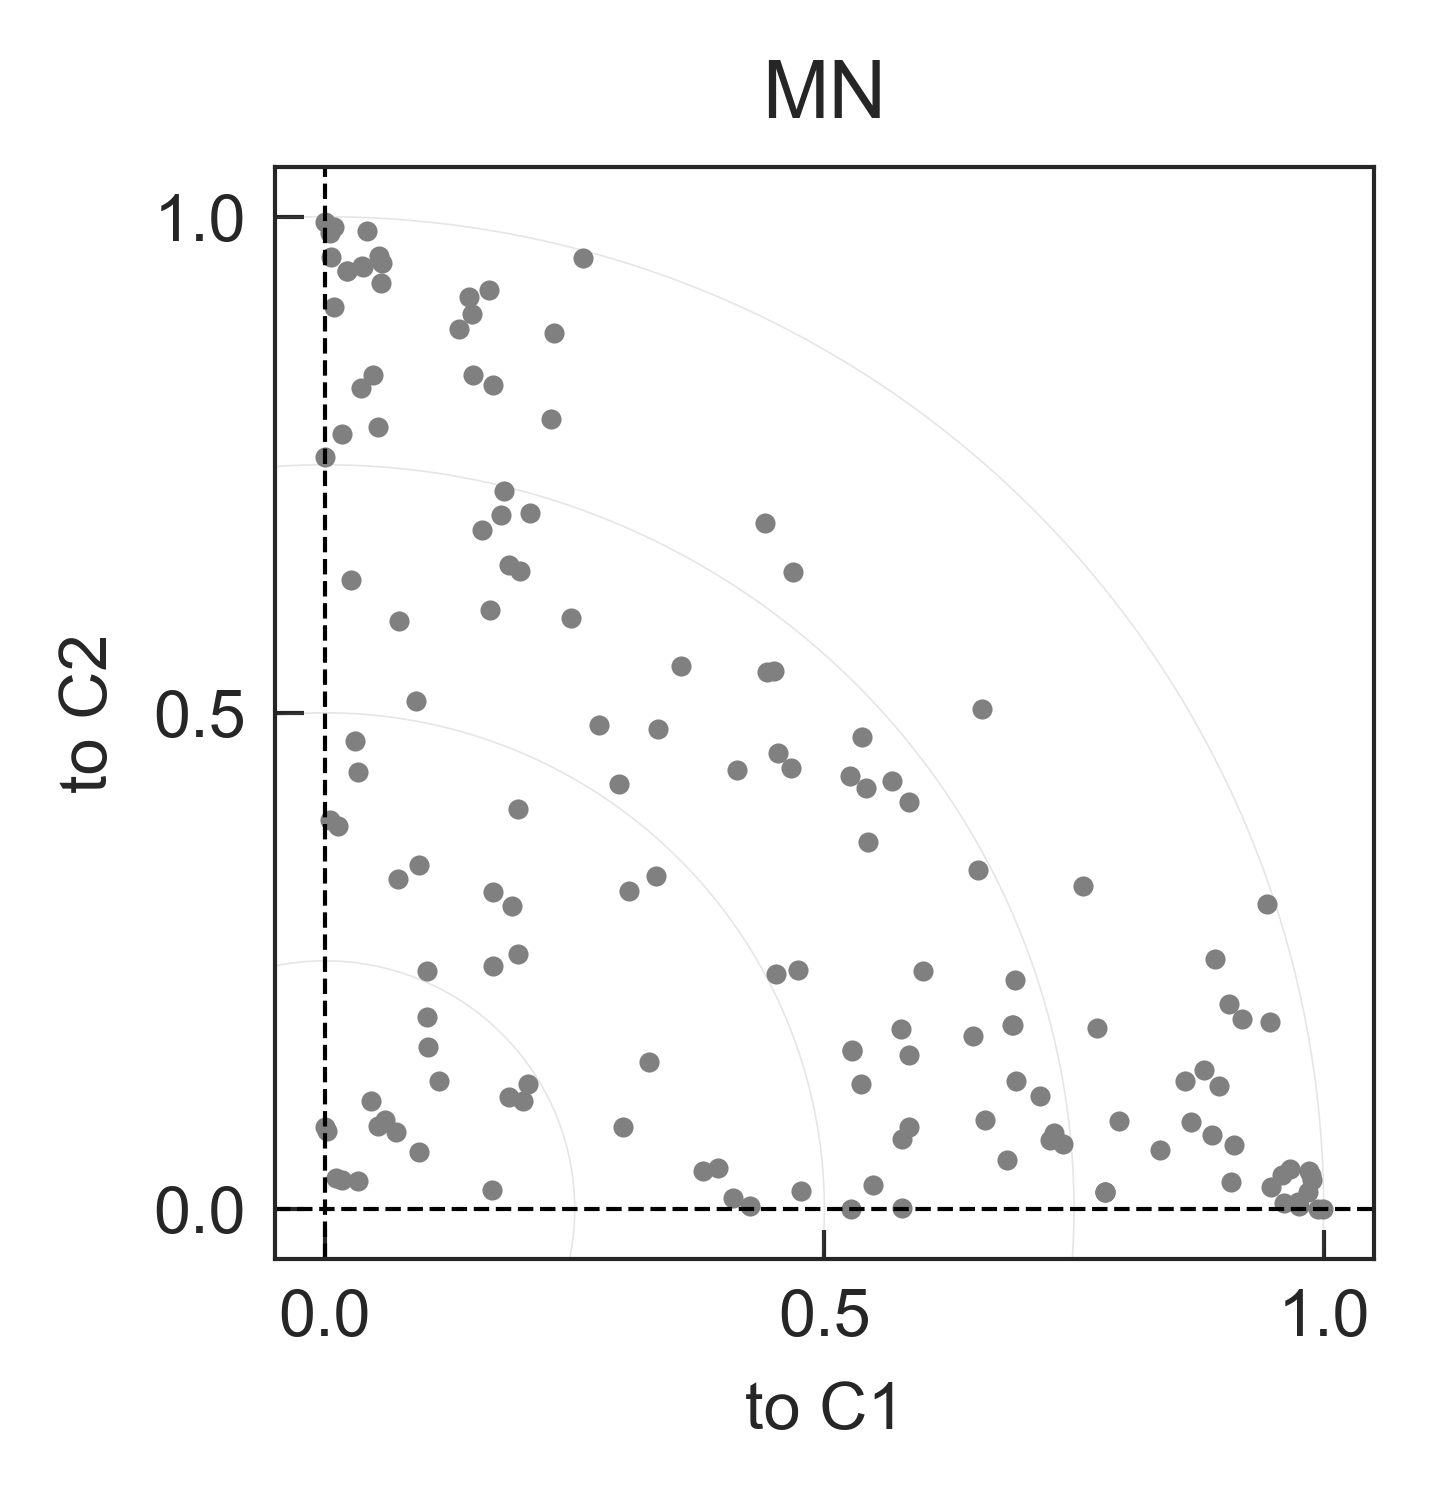

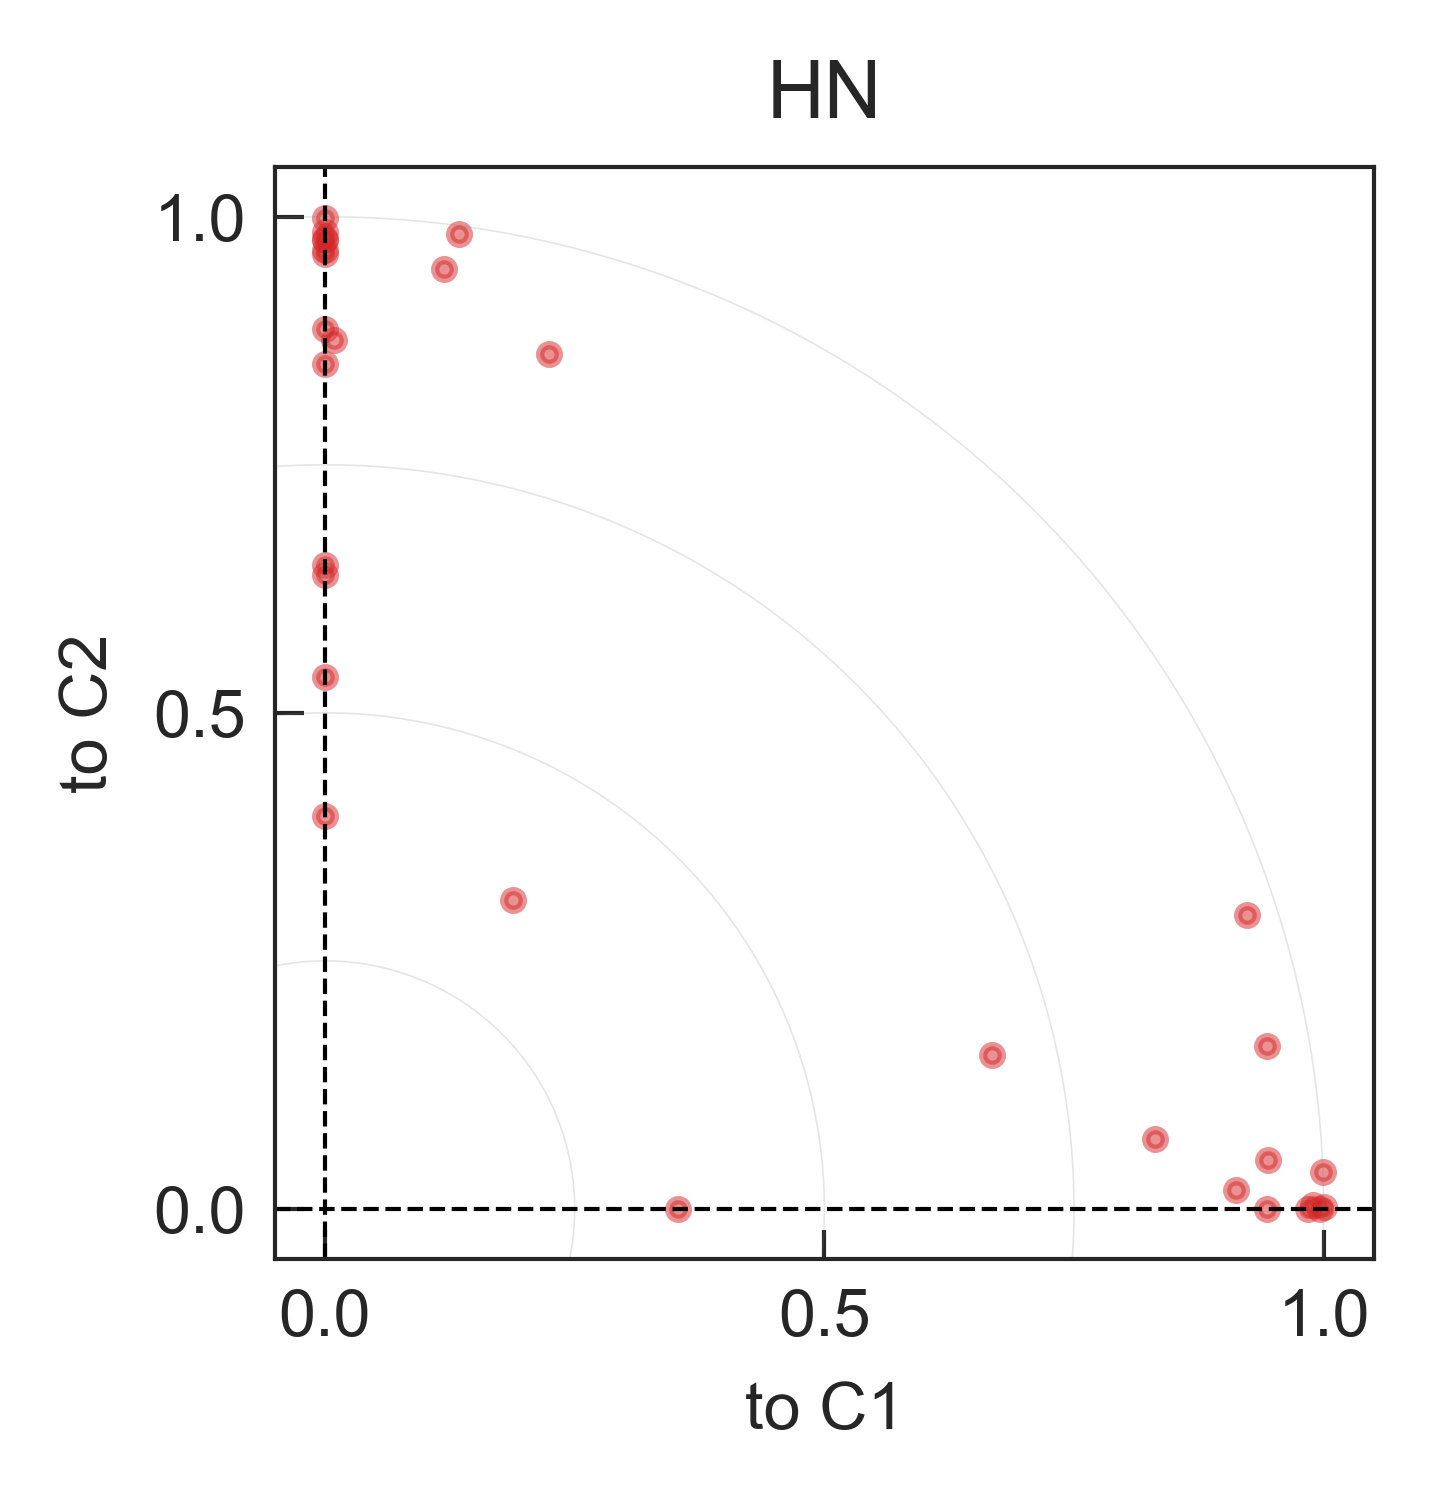

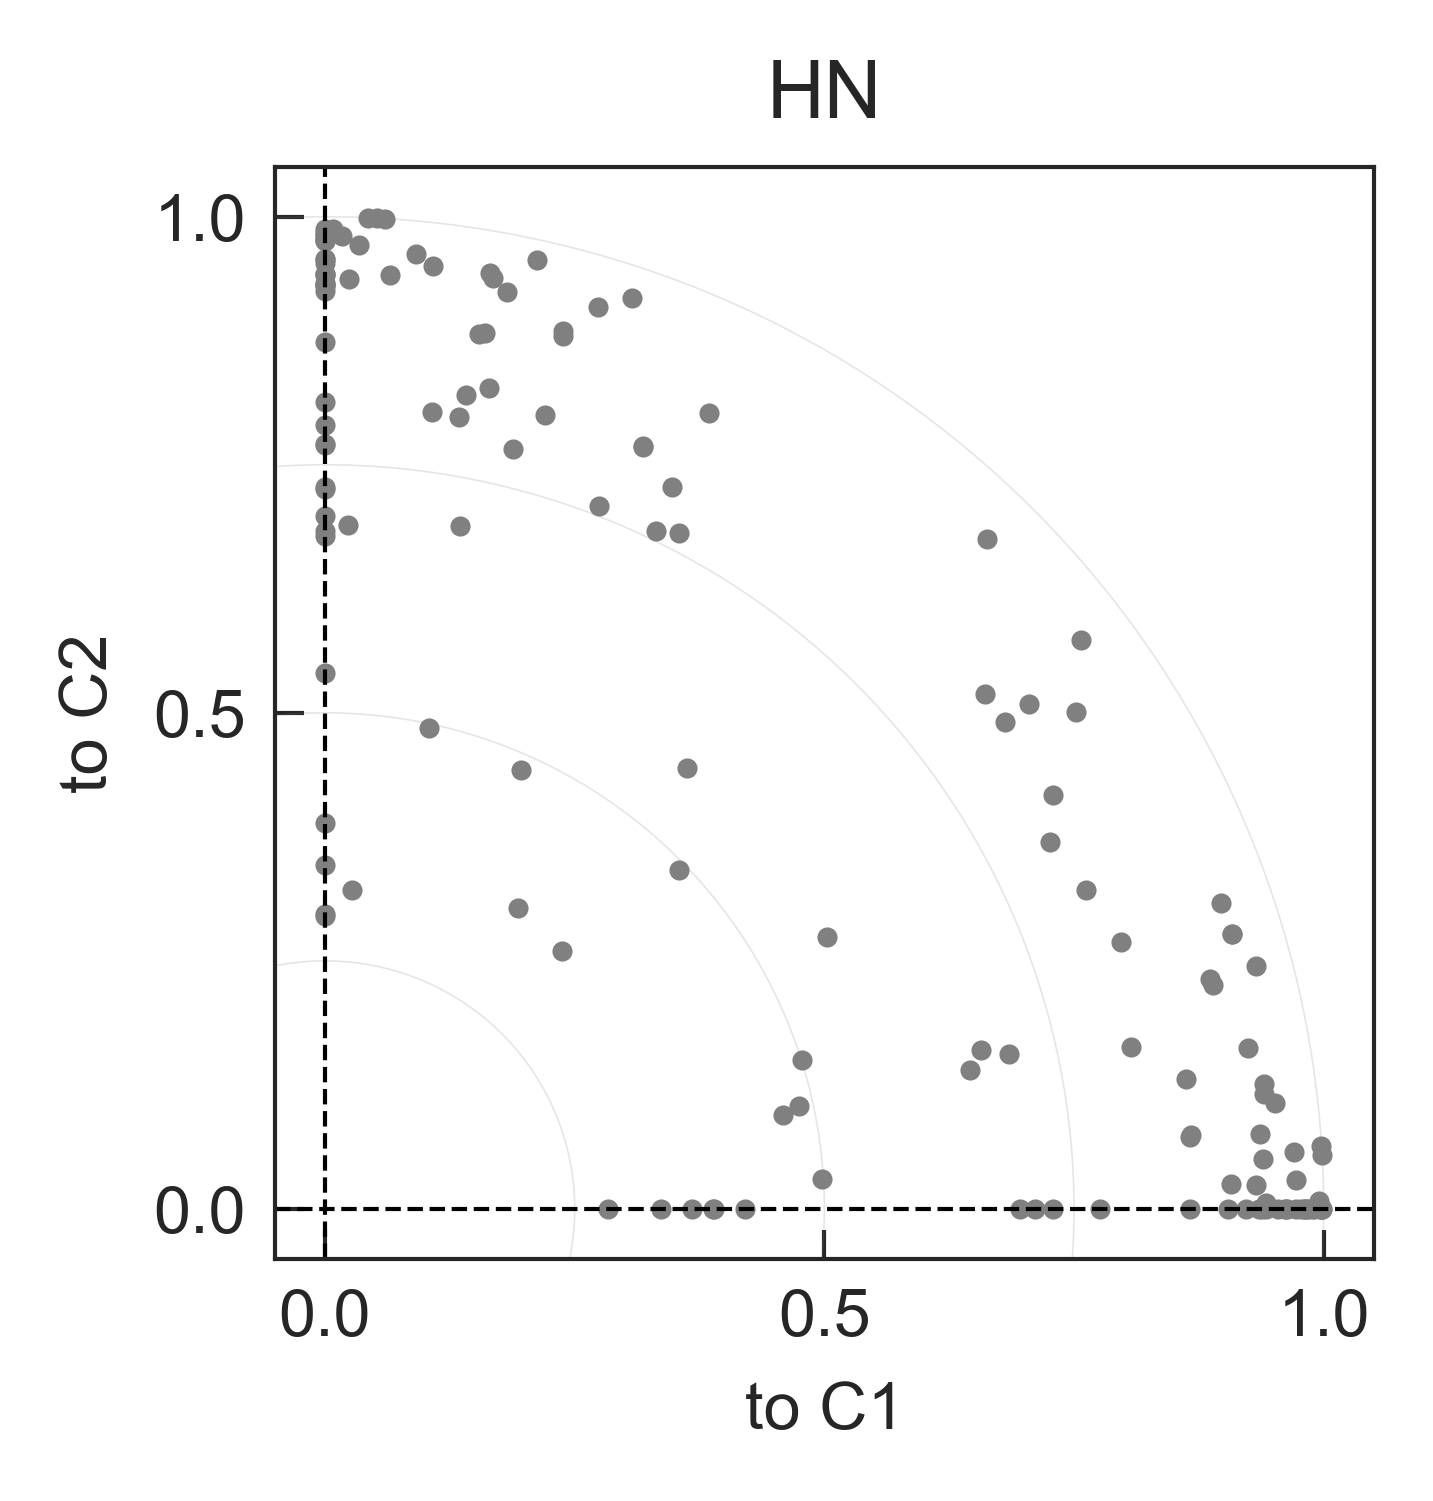

In [12]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

# Plotting real data
degList=np.zeros(Processed_sequences_natural.iloc[:,1:].shape[1])
for c_i,type_name in enumerate(['LN','MN','HN']):#['LN', 'MN', 'HN']):

    Null_model_rep=5



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        IDX_list = Nat_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in IDX_list])
        data1=[]
        data2=[]
        data3=[]
        data4=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(Null_model_rep):
                c_mix=Processed_sequences_natural.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_natural.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_natural.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))
                if _==0:
                    u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
                    #a=abs(u/np.sqrt(u*u+v*v))
                    #b=abs(v/np.sqrt(u*u+v*v))
                    #u=a
                    #v=b
                    data1.append(u)
                    data2.append(v)
                    if u>0.6 and v>0.6:
                        print(type_name)
                        print(u,v,k)
                        print(i, IDX_list[i])
                        #print("y",Processed_sequences_synthetic.iloc[idx[i]][0])
                        #print("ex1",Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[0])
                        #print("ex2",Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[0])
                u,v,k=metric_VectorDecomposition_onlyPositive(moc_c1,moc_c2,c_mix)
                data3.append(u)
                data4.append(v)
                #data_null_model.append(metric2(moc_c1,moc_c2,c_mix))
        print(len(data1))
        data_null_model = np.array(data_null_model)
        data_null_model = data_null_model.reshape([-1,Null_model_rep])
        #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        scatter(data1,data2,s=5,alpha=0.5,color=colors[c_i])

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.2)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('to C1')
        plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])

        plt.title(f'{type_name}')
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{type_name}_style1.svg',bbox_inches='tight')


        f, ax = plt.subplots(1, 1, figsize=(60*mm, 60*mm), facecolor='w', edgecolor='k')
        scatter(data3, data4, s=2, color="grey")

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))

        # Create a faint gray contour line
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.2)

        '''
        # Create a contour plot of the radius
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75,  1], alpha=0.5)

        # Set labels for the contour lines
        contour.collections[0].set_label('r=0.25')
        contour.collections[1].set_label('r=0.5')
        contour.collections[2].set_label('r=0.75')
        contour.collections[3].set_label('r=1')
        '''
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)
        #plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('to C1')
        plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        plt.title(f'{type_name}')
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{type_name}_style1_moc.svg',bbox_inches='tight')




        

(0.22431628768445563, 0.8613312209082397, 0.4558406859508985)

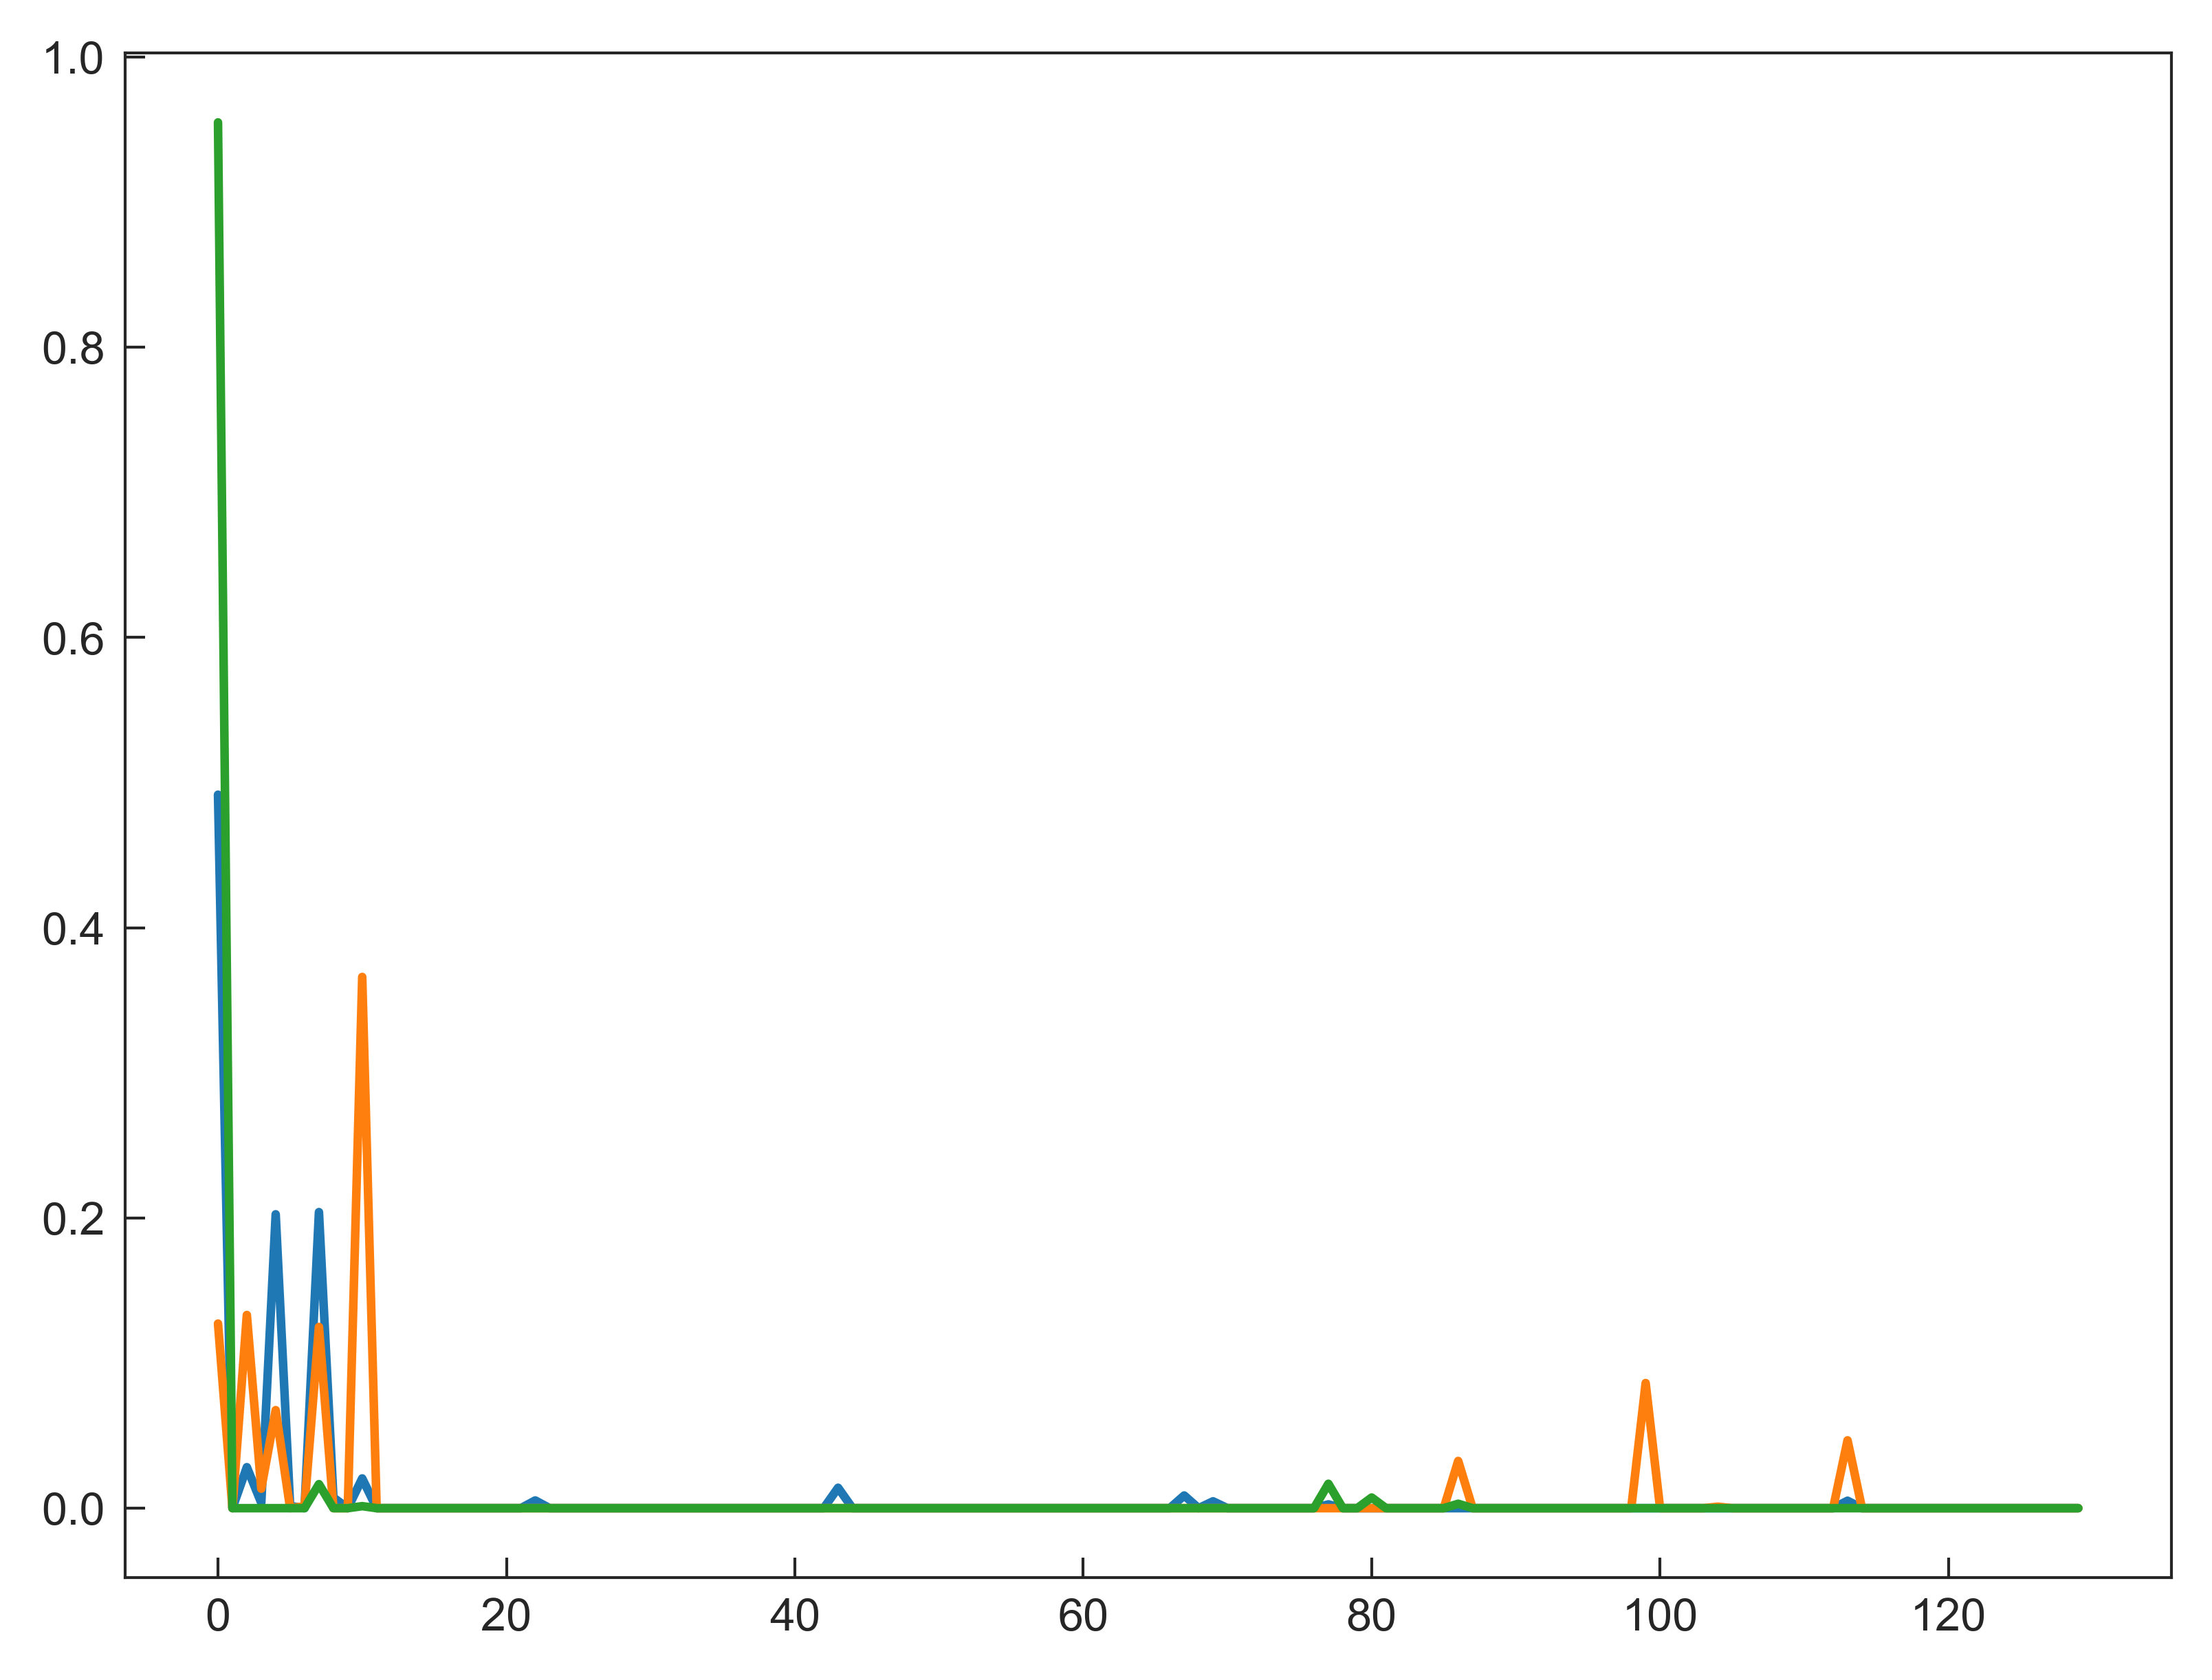

In [13]:
plot(c_mix)
plot(c_1)
plot(c_2)
u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
u,v,k

In [14]:
Nat_Coal_IDX['LN']

['P7-62',
 'P7-85',
 'P7-26',
 'P7-51',
 'P7-50',
 'P7-27',
 'P7-15',
 'P7-87',
 'P7-61',
 'P7-03',
 'P7-28',
 'P7-14',
 'P7-73',
 'P7-25',
 'P7-40',
 'P7-49',
 'P7-75',
 'P7-37',
 'P7-16',
 'P7-39',
 'P7-74',
 'P7-52',
 'P7-63',
 'P7-04',
 'P7-01',
 'P7-64',
 'P7-38',
 'P7-13',
 'P7-76',
 'P7-02']

In [15]:
Processed_sequences_natural.iloc[:,1:].shape[1]

130

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/2242777796.py:122: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/2242777796.py:162: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data3)/np.array(data4)))-np.pi/4)/(np.pi/4)


LN 0.47109411260915324 0.3104894722815843
LN 0.81787913842686 0.10149041350147683
LN 0.37266349878944033 0.25756576641549545
MN 0.7309050024225914 0.28317243203661885
MN 0.8937786223801778 0.09658395473389592
MN 0.49650709556446665 0.30343584690765235
HN 0.7857387765032239 0.22712673206739115
HN 0.9149301582760769 0.08101428212460723
HN 0.6397089069289629 0.3147472892122307


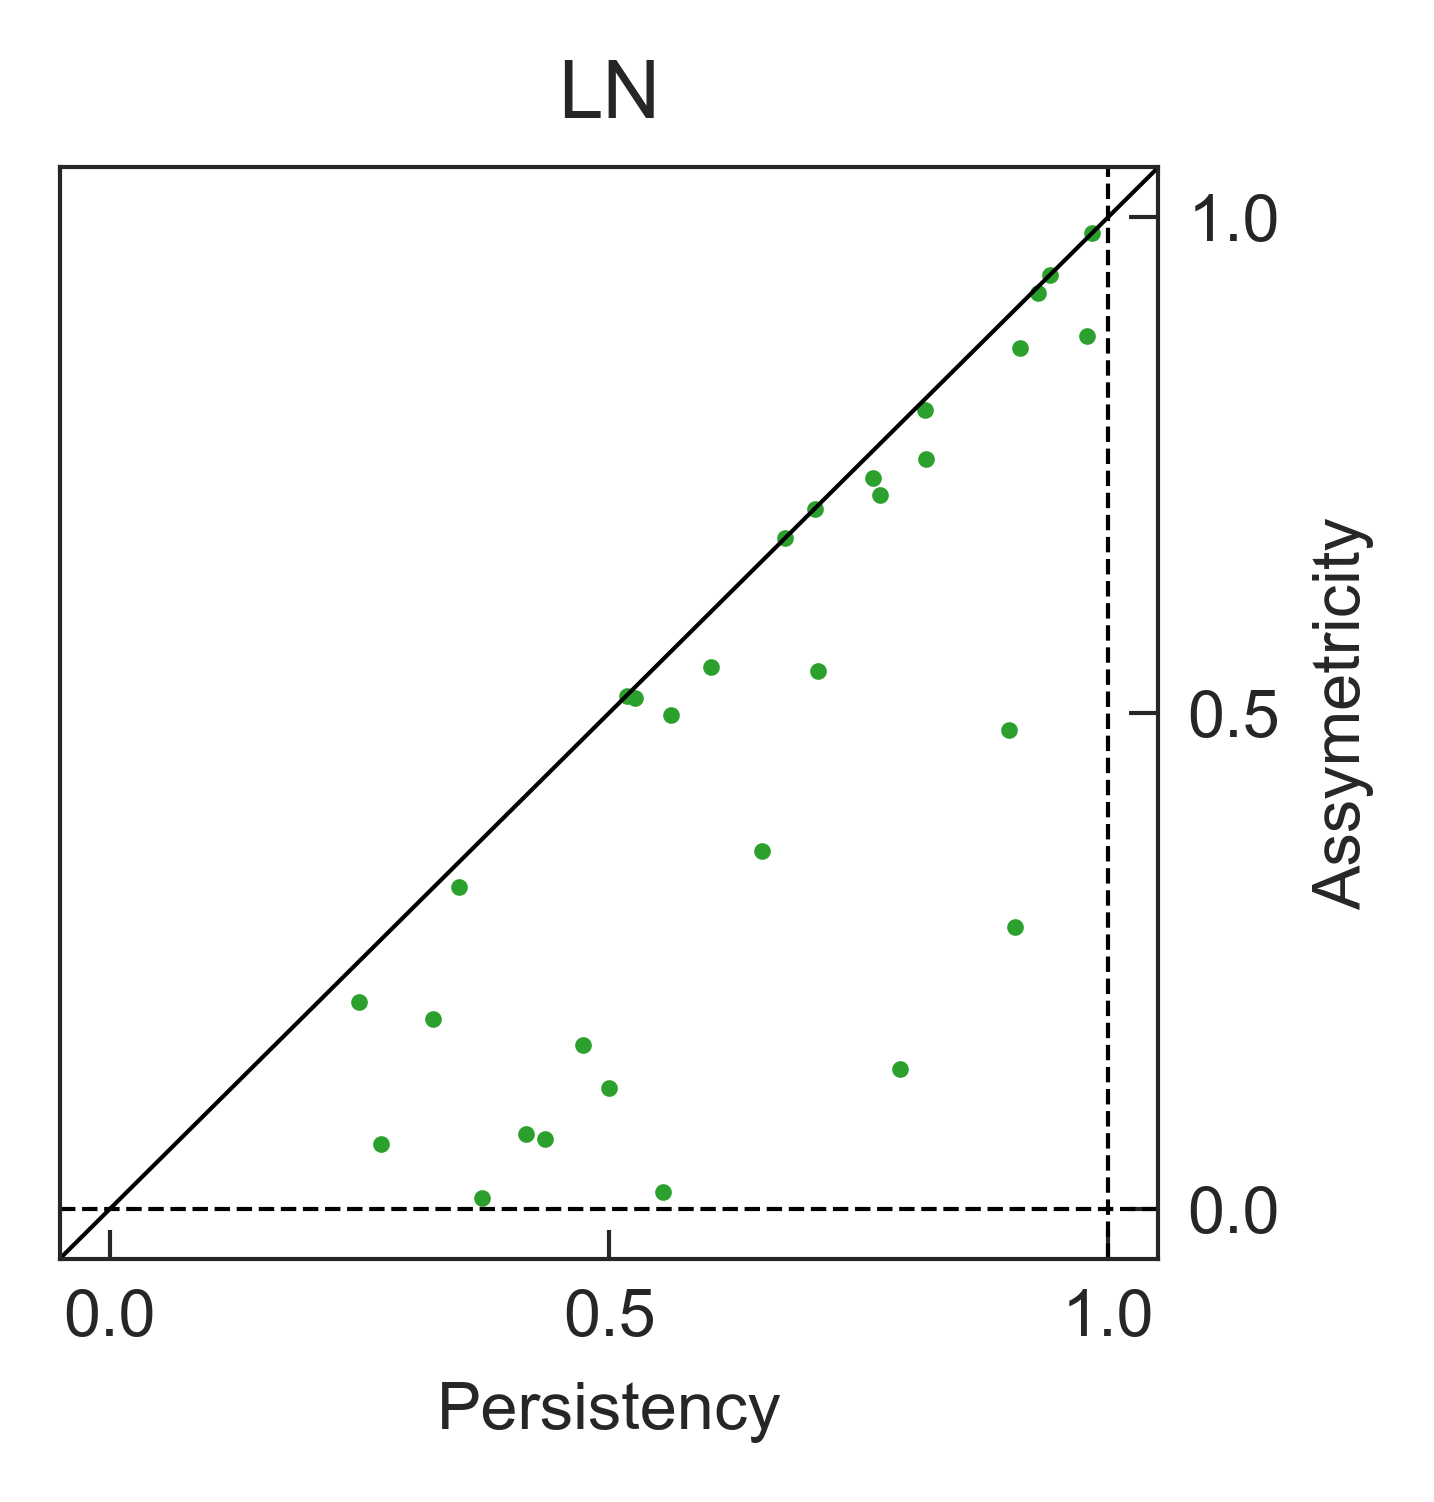

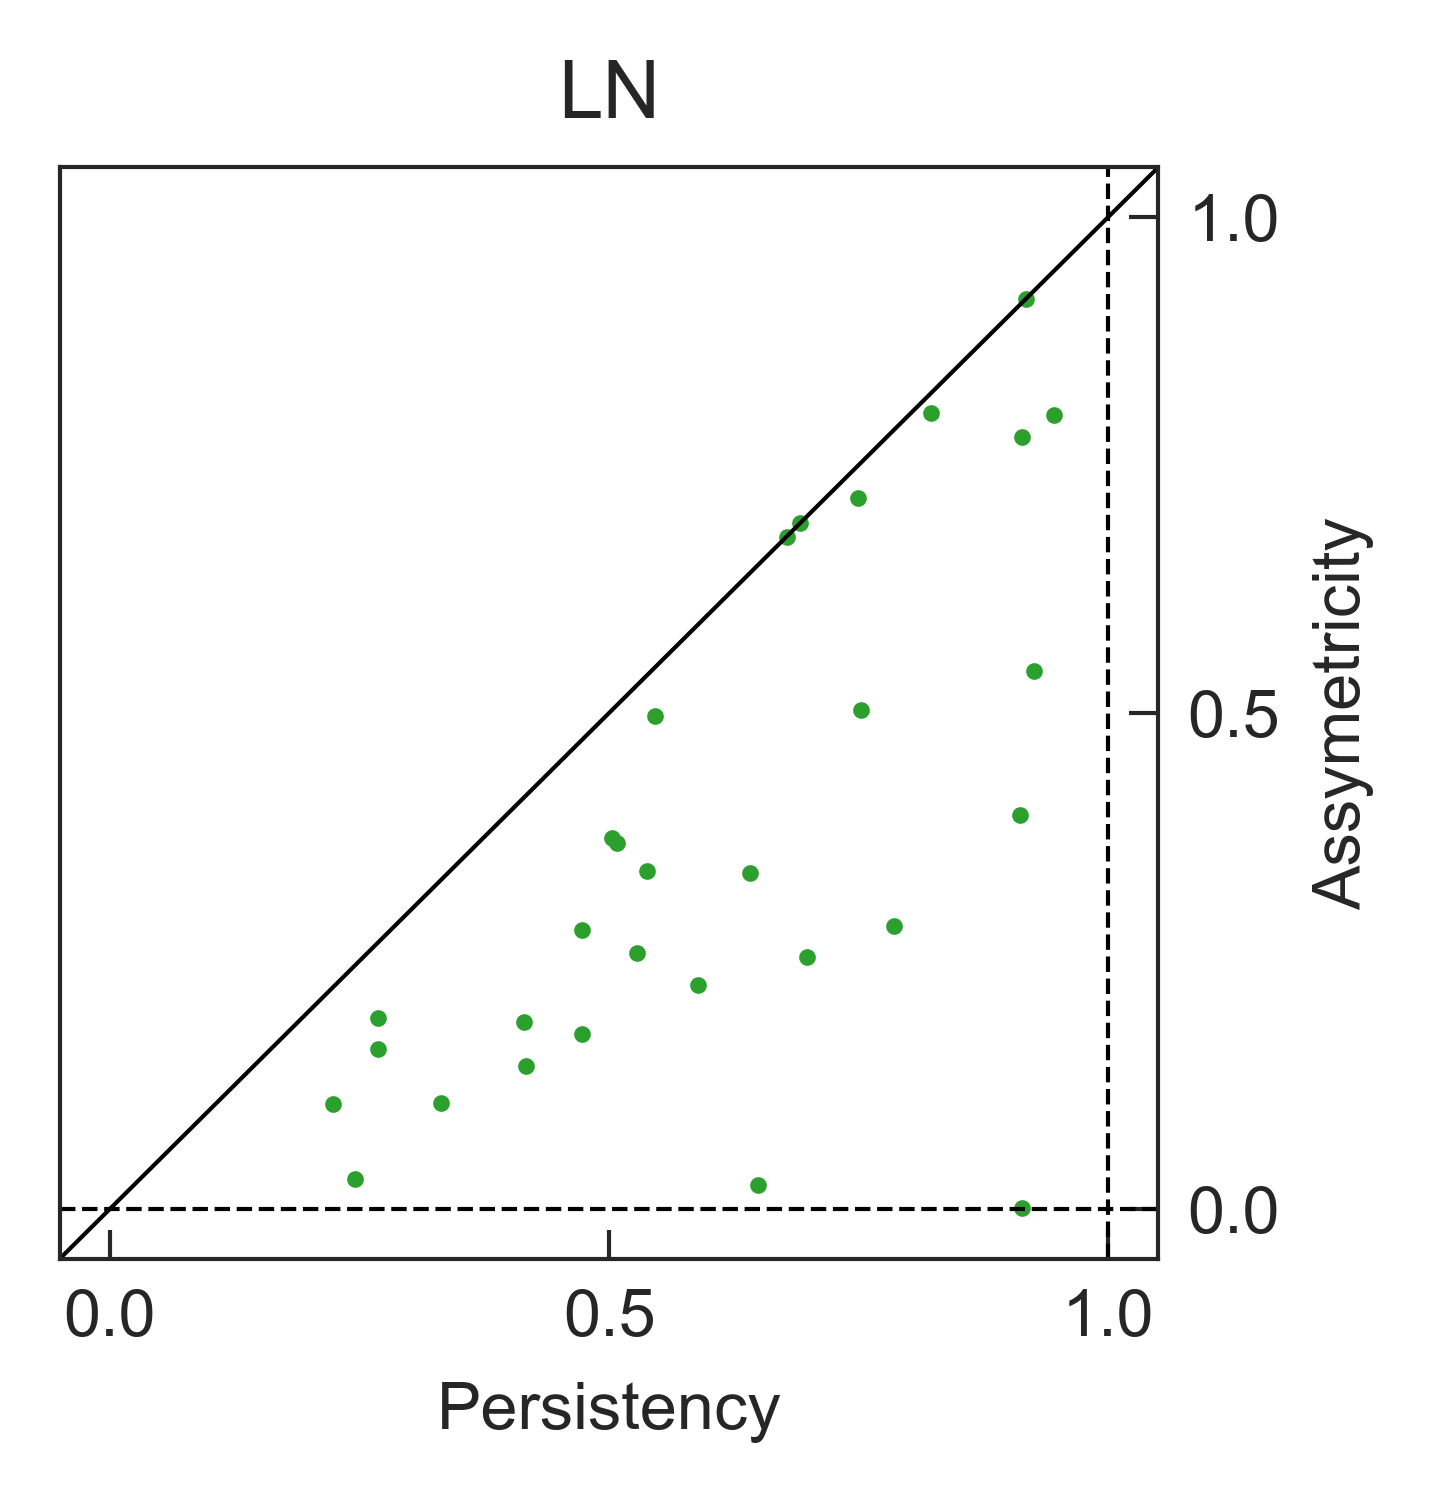

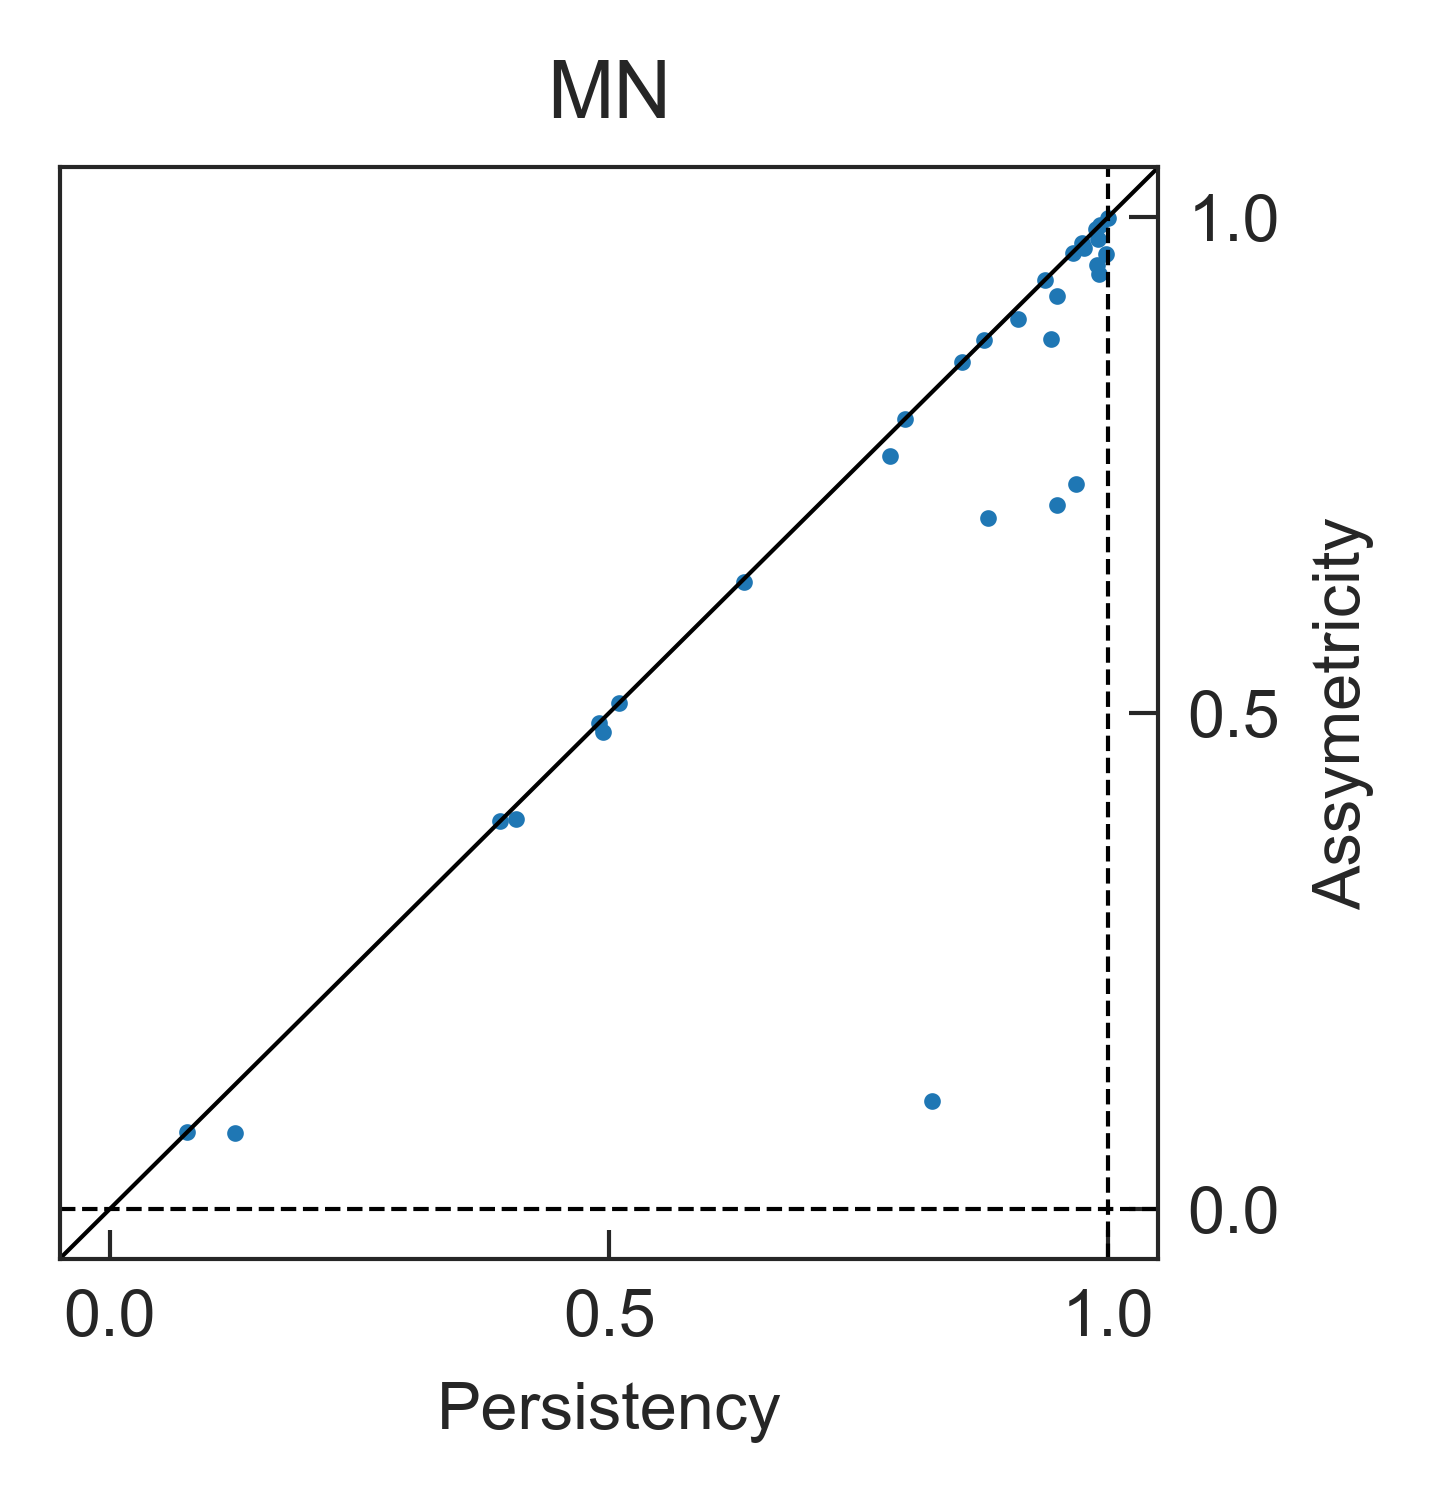

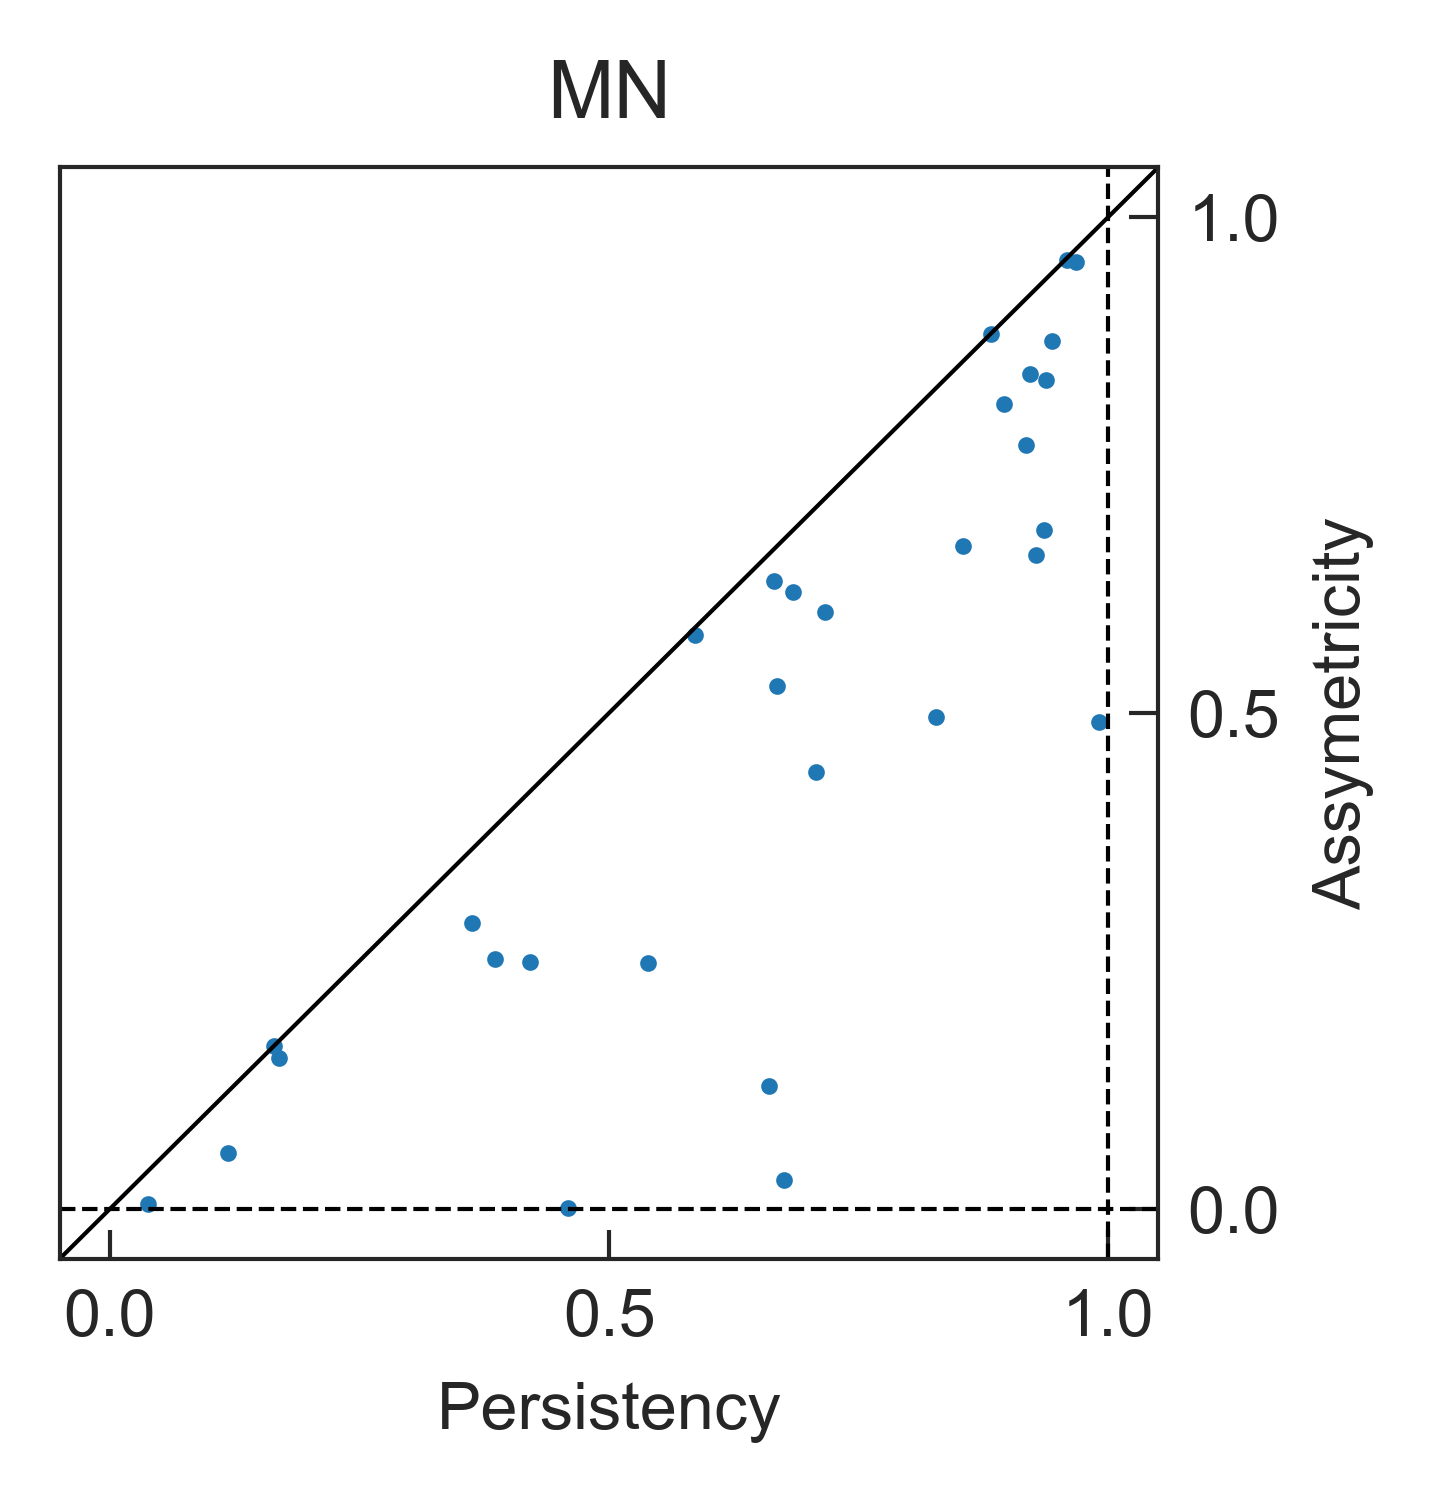

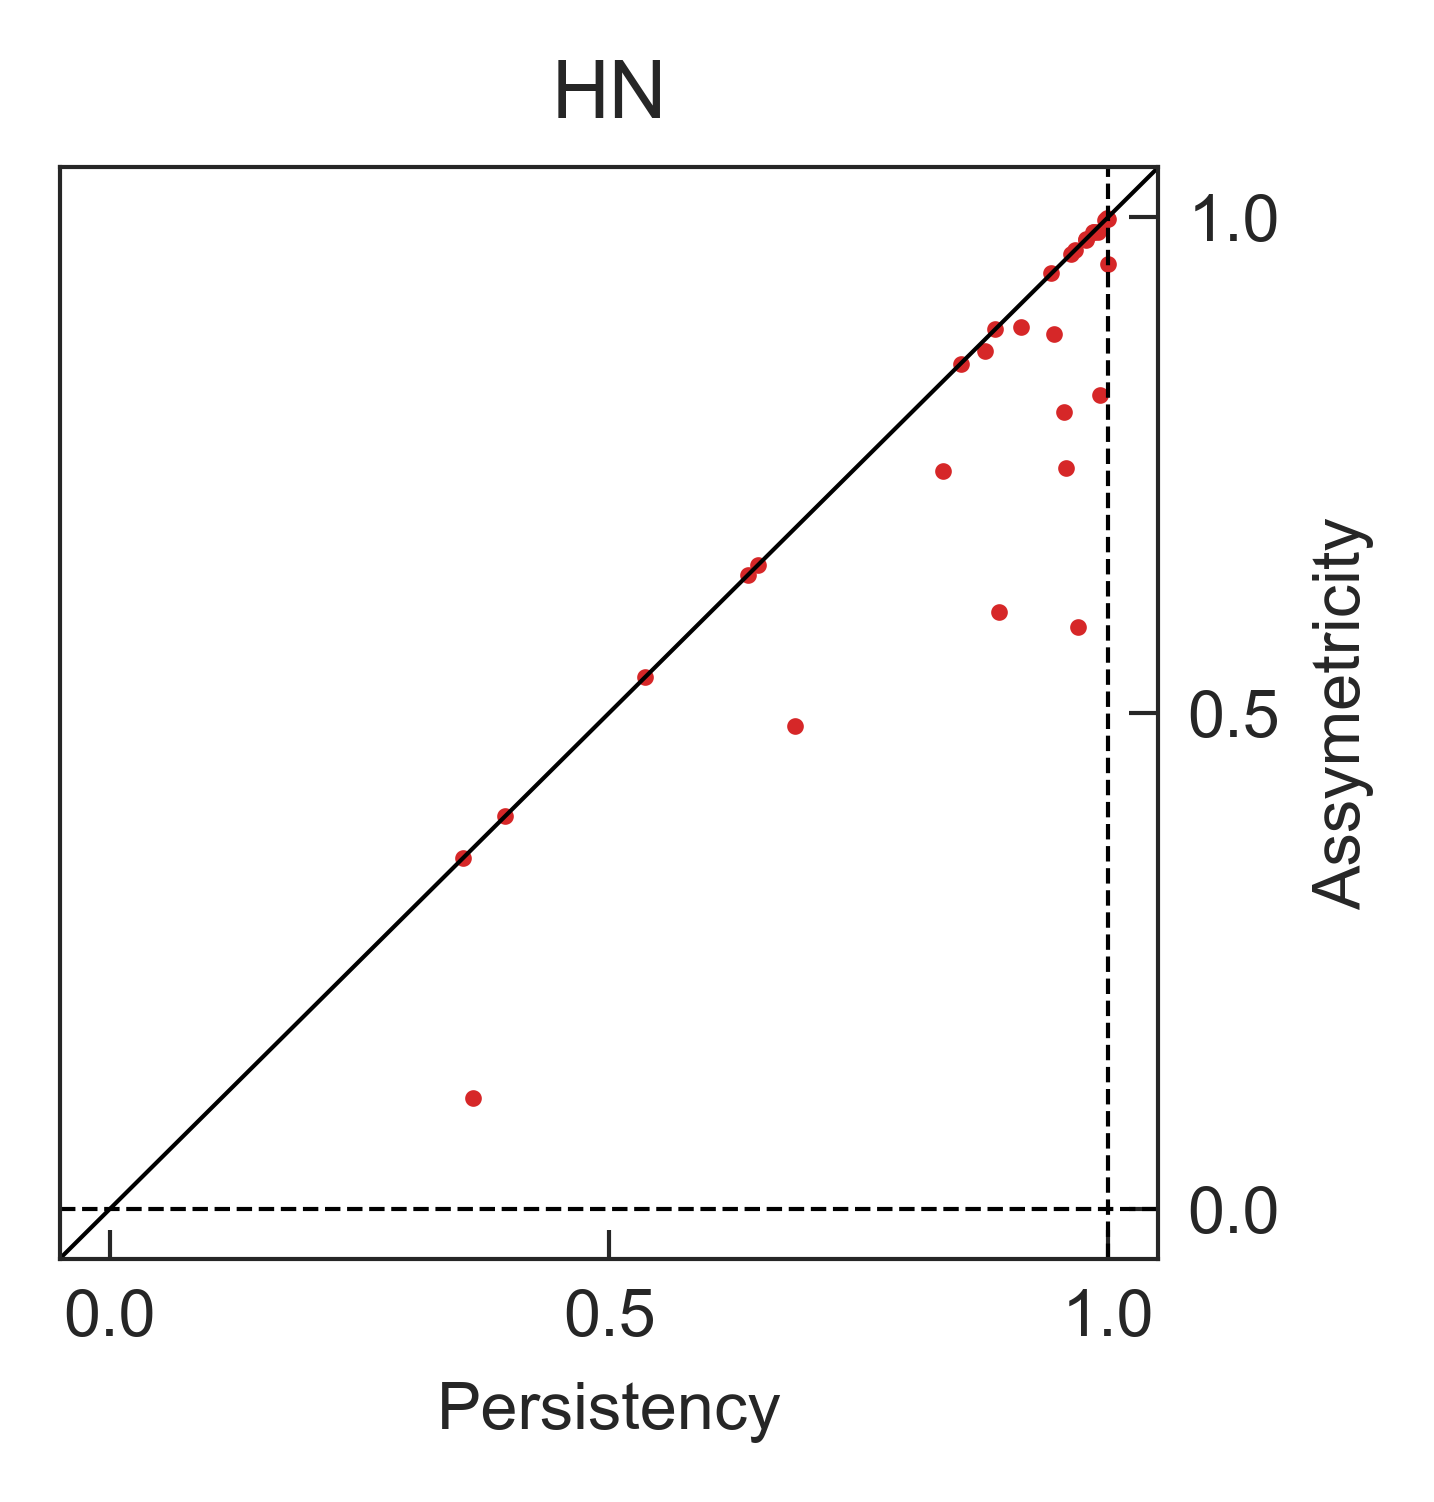

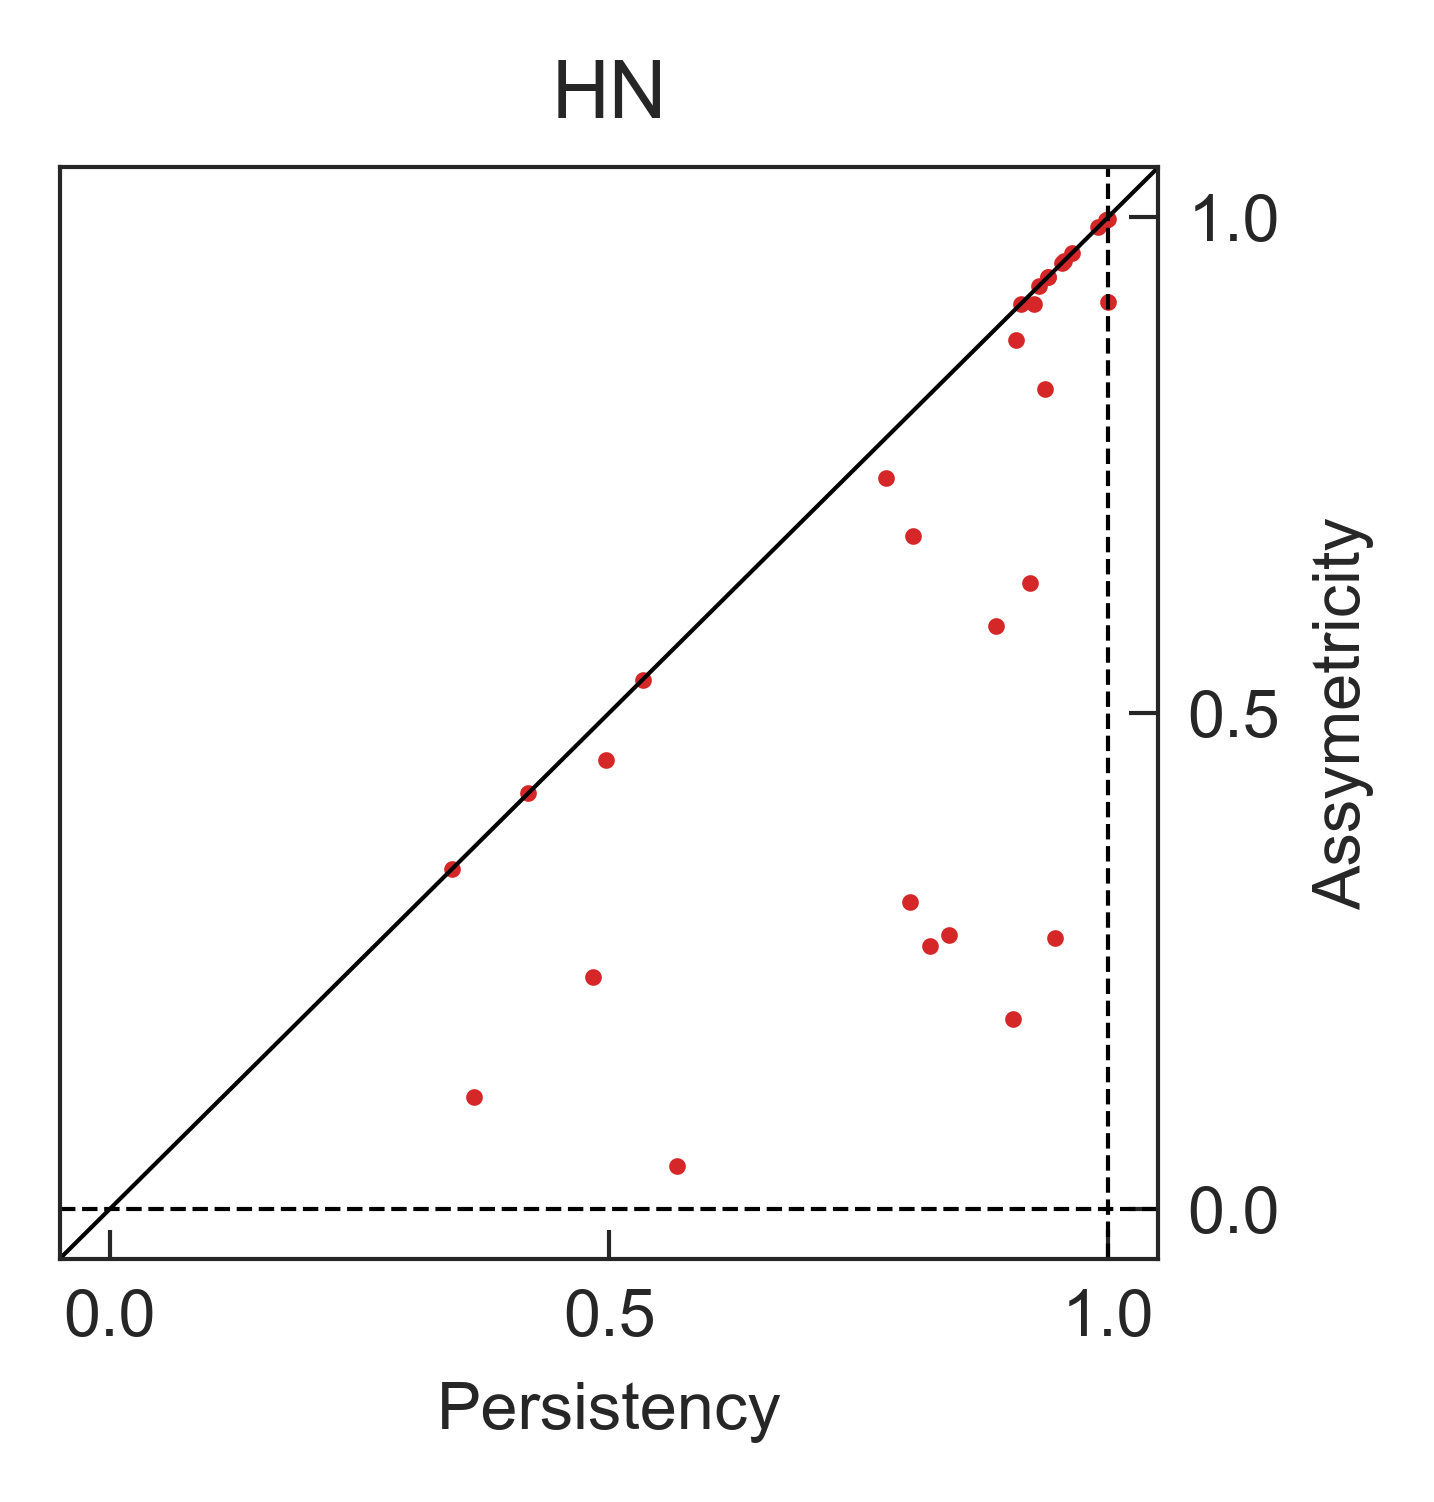

In [16]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data
degList=np.zeros(Processed_sequences_natural.iloc[:,1:].shape[1])
for c_i,type_name in enumerate(['LN', 'MN', 'HN']):

    Null_model_rep=1



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        IDX_list = Nat_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in IDX_list])
        
        data1=[]
        data2=[]
        data3=[]
        data4=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(Null_model_rep):
                c_mix=Processed_sequences_natural.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_natural.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_natural.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=0.25
                moc_c2=0.25
                while np.sum(moc_c1)<0.5 or np.sum(moc_c2)<0.5:
                    moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                    moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                    moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                    moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))
                if _==0:
                    u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
                    #a=abs(u/np.sqrt(u*u+v*v))
                    #b=abs(v/np.sqrt(u*u+v*v))
                    #u=a
                    #v=b
                    data1.append(u)
                    data2.append(v)
                    
                    if u>0.6 and v>0.6:
                        print(type_name)
                        print(u,v,k)
                        print(i, IDX_list[i])
                        #print("y",Processed_sequences_synthetic.iloc[idx[i]][0])
                        #print("ex1",Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[0])
                        #print("ex2",Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[0])
                u,v,k=metric_VectorDecomposition_onlyPositive(moc_c1,moc_c2,c_mix)
                data3.append(u)
                data4.append(v)
                #data_null_model.append(metric2(moc_c1,moc_c2,c_mix))

        data_null_model = np.array(data_null_model)
        data_null_model = data_null_model.reshape([-1,Null_model_rep])
        #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

       
        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        
        x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
        y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
        print(type_name,np.mean(x*y), np.std(x*y))
        z=x*y
        print(type_name,np.mean(z[z>0.66]), np.std(z[z>0.66]))

        scatter(x,x*y,s=1,color=colors[c_i])

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Add auxiliary lines at x=0 and y=0
        
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")


        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, color='k', linestyle='--', linewidth=.5)
        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        plt.xlabel('Persistency')
        plt.ylabel('Assymetricity')
        plt.title(f'{type_name}')
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{type_name}_style1.svg',bbox_inches='tight')


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        x=np.sqrt(np.array(data3)**2+np.array(data4)**2)
        y=np.abs(np.abs(np.arctan(np.array(data3)/np.array(data4)))-np.pi/4)/(np.pi/4)
        print(type_name,np.mean(x*y), np.std(x*y))

        scatter(x,x*y,s=1,color=colors[c_i])

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)
        
        plt.plot([-1, 2], [-1, 2], 'black', label='x = y', linewidth=.5)  # Add the line x = y


        # Calculate the radius from the origin
        
        '''
        # Create a contour plot of the radius
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75,  1], alpha=0.5)

        # Set labels for the contour lines
        contour.collections[0].set_label('r=0.25')
        contour.collections[1].set_label('r=0.5')
        contour.collections[2].set_label('r=0.75')
        contour.collections[3].set_label('r=1')
        '''
        # Add auxiliary lines at x=0 and y=0
        ax.yaxis.set_label_position("right")
        ax.yaxis.set_ticks_position("right")

        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(1, color='k', linestyle='--', linewidth=.5)
        plt.clabel(contour, inline=1, fontsize=5, fmt='r=%.2f')


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        plt.xlabel('Persistency')
        plt.ylabel('Assymetricity')
        plt.title(f'{type_name}')
        #plt.legend()
        #f.savefig(f'Figure/Metric_metric3_{type_name}_style1_moc.svg',bbox_inches='tight')




        

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/2615510163.py:70: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


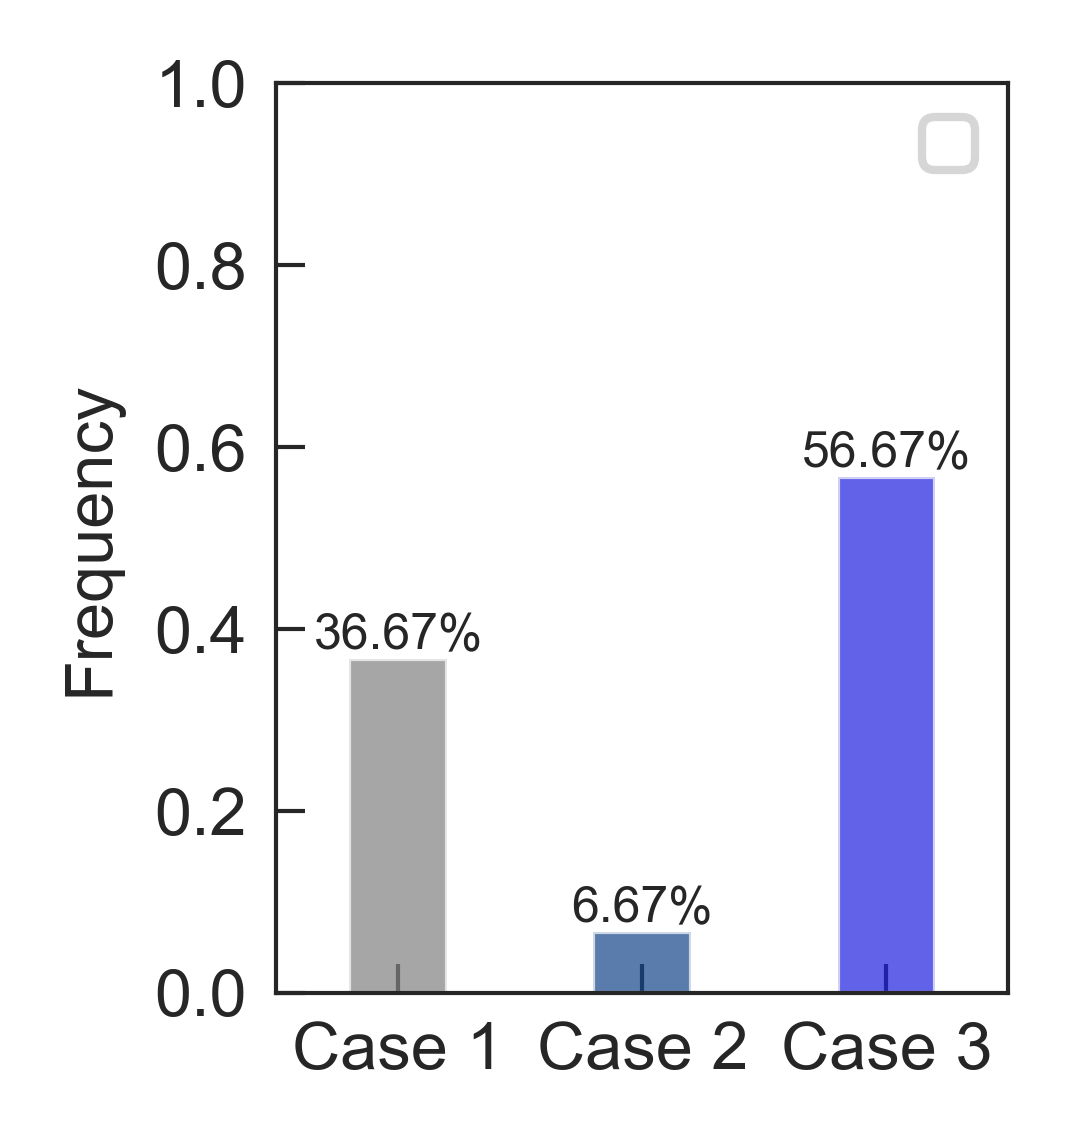

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/2615510163.py:70: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


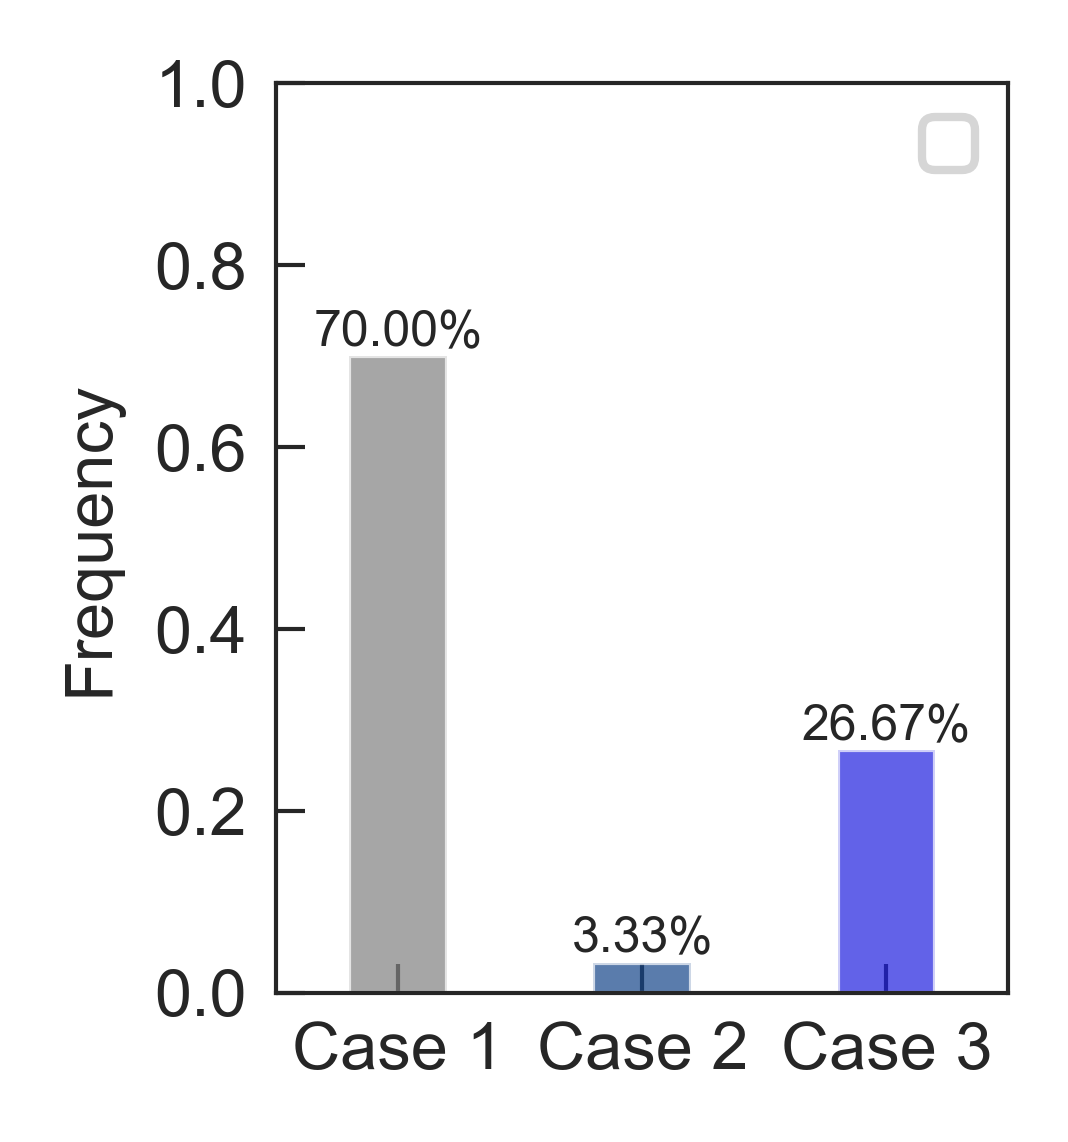

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/2615510163.py:70: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


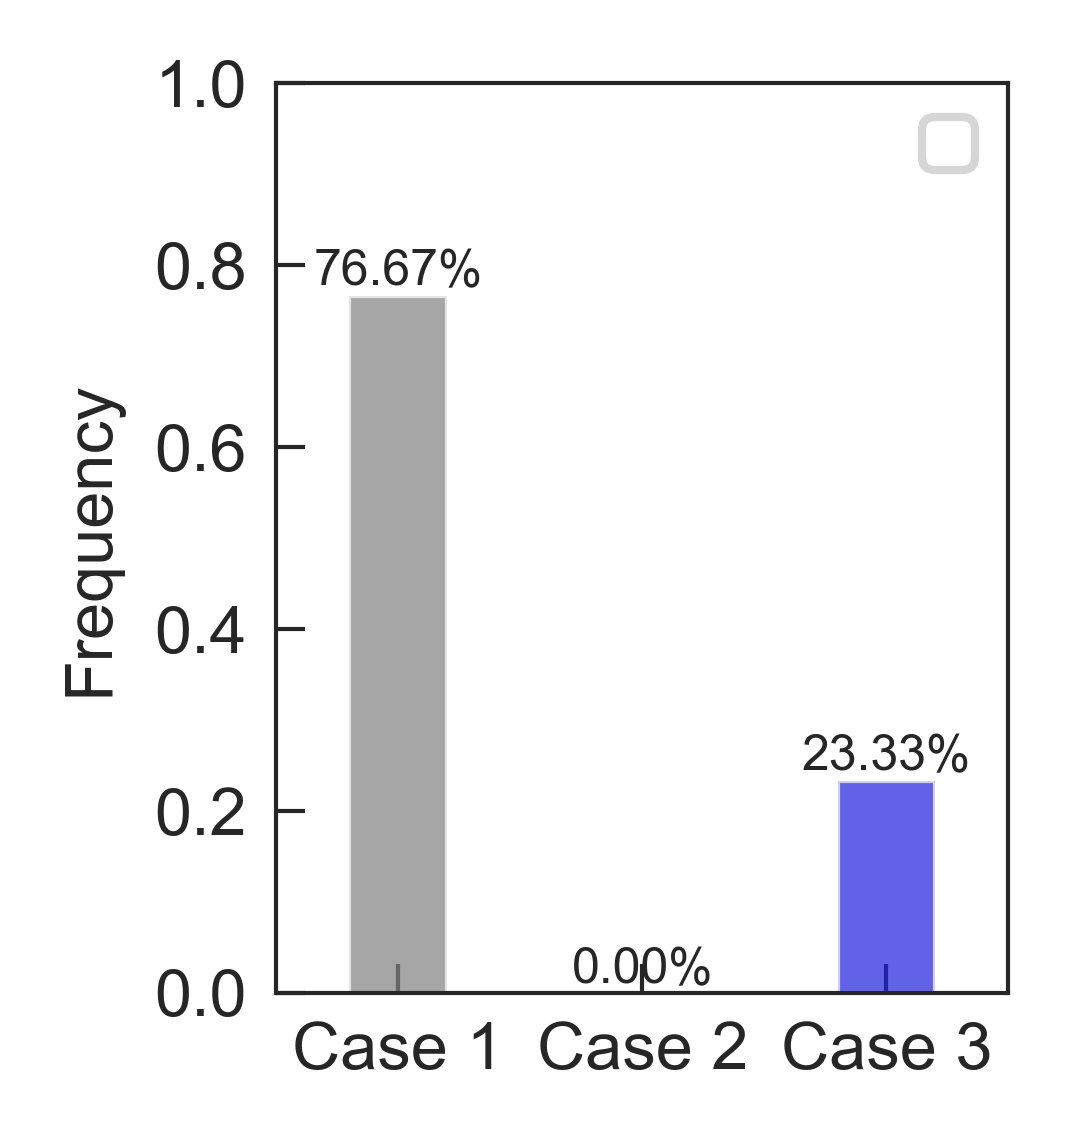

In [17]:
for c_i,type_name in enumerate(['LN', 'MN', 'HN']):

    Null_model_rep=1



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        IDX_list = Nat_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in IDX_list])
        data1=[]
        data2=[]
        data3=[]
        data4=[]
        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(Null_model_rep):
                c_mix=Processed_sequences_natural.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_natural.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_natural.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=0.25
                moc_c2=0.25
                while np.sum(moc_c1)<0.5 or np.sum(moc_c2)<0.5:
                    moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                    moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                    moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                    moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))
                if _==0:
                    u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
                    #a=abs(u/np.sqrt(u*u+v*v))
                    #b=abs(v/np.sqrt(u*u+v*v))
                    #u=a
                    #v=b
                    data1.append(u)
                    data2.append(v)
                    
                    if u>0.6 and v>0.6:
                        print(type_name)
                        print(u,v,k)
                        print(i, IDX_list[i])
                        #print("y",Processed_sequences_synthetic.iloc[idx[i]][0])
                        #print("ex1",Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[0])
                        #print("ex2",Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[0])
                u,v,k=metric_VectorDecomposition_onlyPositive(moc_c1,moc_c2,c_mix)
                data3.append(u)
                data4.append(v)
                #data_null_model.append(metric2(moc_c1,moc_c2,c_mix))

        data_null_model = np.array(data_null_model)
        data_null_model = data_null_model.reshape([-1,Null_model_rep])
        

    x=np.sqrt(np.array(data1)**2+np.array(data2)**2)
    y=np.abs(np.abs(np.arctan(np.array(data1)/np.array(data2)))-np.pi/4)/(np.pi/4)

    case1=np.sum((x**2>0.5)*(y>0.5))/len(x)
    case2=np.sum((x**2>0.5)*(y<0.5))/len(x)
    case3=np.sum((x**2<0.5))/len(x)

    combined_data = np.squeeze(np.array([case1, case2, case3]))
    labels = ['Case 1'] + ['Case 2'] + ['Case 3']
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Case 1', 'Case 2', 'Case 3'], width=0.4,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Case 1": "grey", 'Case 2': my_cmap(0), "Case 3": "blue"})
    for i, val in enumerate(combined_data):
        ax.text(i, val, f'{val:.2%}', ha='center', va='bottom', fontsize=6)

    plt.ylim(0, 1)
    plt.ylabel('Frequency')
    plt.xlabel('')
    plt.legend()
    plt.show()

    f.savefig(f'Figure/Fig_cases_{type_name}.svg',bbox_inches='tight')


In [18]:
# Plotting real data
degList=np.zeros(Processed_sequences_natural.iloc[:,1:].shape[1])

data1_set={}
data2_set={}
data3_set={}
for c_i,type_name in enumerate(['LN', 'MN', 'HN']):
    Null_model_rep=1
    IDX_list = Nat_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_natural['SampleIDX']==x) for x in IDX_list])
    data1=[]
    data2=[]
    data3=[]
    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        c_mix=Processed_sequences_natural.iloc[idx[i]].values.tolist()[1:]
        c_1=np.array(Processed_sequences_natural.iloc[idx_1[i]].values.tolist()[1:])
        c_2=np.array(Processed_sequences_natural.iloc[idx_2[i]].values.tolist()[1:])
        c_1=c_1*(c_1>1e-4)
        c_2=c_2*(c_2>1e-4)
        '''
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)
        '''
        u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
        data1.append(u)
        data2.append(v)
        data3.append(k)

    data1_set[type_name] = data1
    data2_set[type_name] = data2
    data3_set[type_name] = data3


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_30929/3540836627.py:26: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


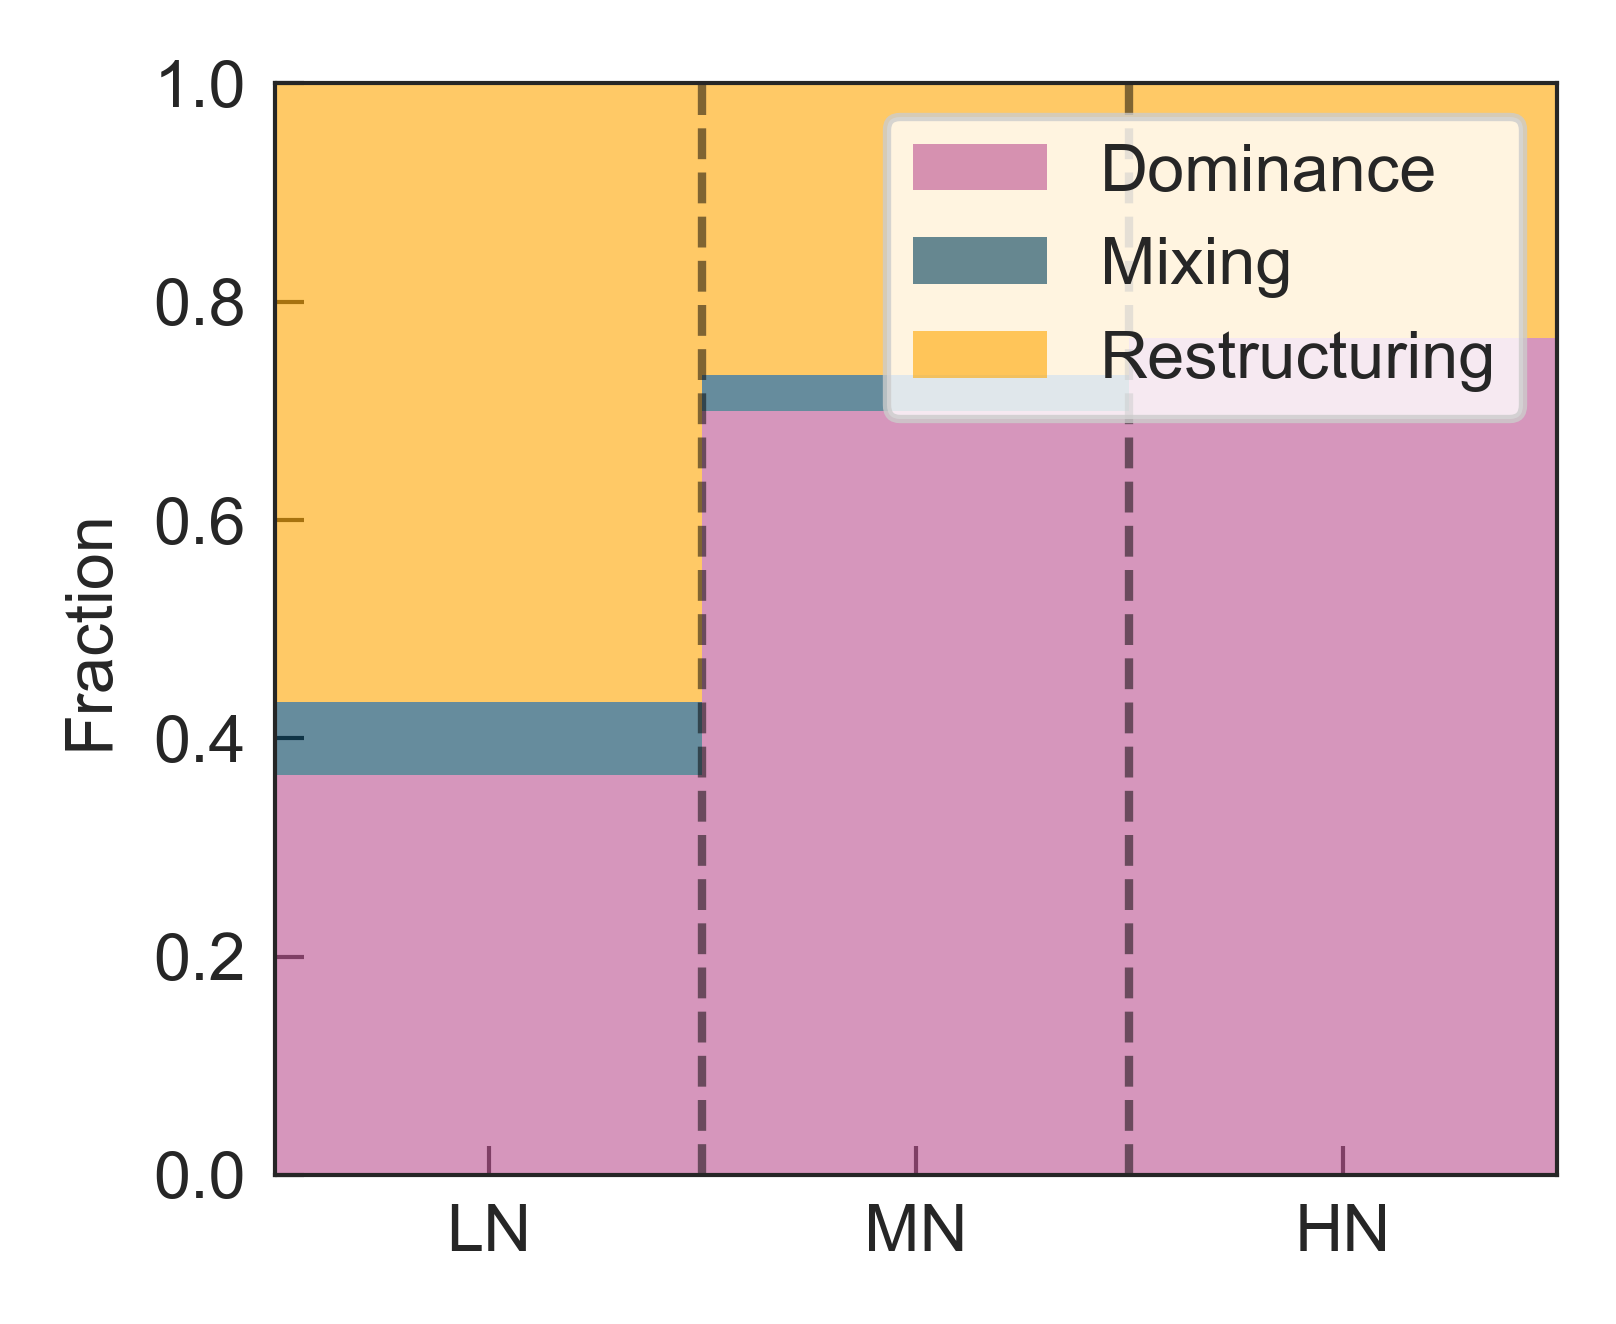

In [19]:
class1_fractions=np.zeros(4)
class2_fractions=np.zeros(4)
class3_fractions=np.zeros(4)

colors = ['#bc5090', '#003f5c','#ffa600' ]


for c_i,type_name in enumerate(['LN', 'MN', 'HN']):

    class1_count=0
    class2_count=0
    class3_count=0
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        if ii==0:
            class1_count+=1
        if ii==1:
            class2_count+=1
        if ii==2:
            class3_count+=1
    total_count=class1_count+class2_count+class3_count
    class1_fractions[c_i]=class1_count/total_count
    class2_fractions[c_i]=class2_count/total_count
    class3_fractions[c_i]=class3_count/total_count
    
f, ax = plt.subplots(1, figsize=(70*mm,60*mm),facecolor='w', edgecolor='k')

    
# Create a stacked, filled bar plot for each x value
width = 0.5  # Width of the bars

# Create an array of x values for each class to form a connected line
x_values_array = np.array([0,1,2,3])

# Plot each class's fractions as stacked, filled bars
#plt.fill_between(x_values_array, 0, class1_fractions, step='mid', label='Dominance', color=colors[0], alpha=0.6, edgecolor='none')
#plt.fill_between(x_values_array, class1_fractions, class1_fractions + class2_fractions, step='mid', label='Mixing', color=colors[1], alpha=0.6, edgecolor='none')
#plt.fill_between(x_values_array, class1_fractions + class2_fractions, class3_fractions + class2_fractions + class1_fractions, color=colors[2], alpha=0.6, step='mid', label='Restructuring', edgecolor='none')

plt.fill_between(x_values_array, 0, class1_fractions, step='post', label='Dominance', color=colors[0], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions, class1_fractions + class2_fractions, step='post', label='Mixing', color=colors[1], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions + class2_fractions, class3_fractions + class2_fractions + class1_fractions, color=colors[2], alpha=0.6, step='post', label='Restructuring', edgecolor='none')


# Add labels and a legend
#plt.xlabel('Mediums')
plt.ylabel('Fraction')
plt.xlim([0,3])
plt.ylim([0,1])
#plt.title('Stacked and Filled Bar Plot of Three Classes for Each X Value')
plt.legend()

plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0.5, 1.5, 2.5]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=2, color='black', linestyle='--', alpha=0.5, linewidth=1)

# Display the plot
f.savefig(f'Figure/Fig_classes_map.svg',bbox_inches='tight')
plt.show()

mask